# Charger le dataset

In [1]:
import pandas as pd

file_path = r"C:\Users\DELL\Downloads\deep-learning\IOT-temp.csv\IOT-temp.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
df.head()


Dataset loaded successfully


,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


# Examiner la structure du dataset

In [3]:
print("Shape (rows, columns):", df.shape)
print("\nStructure du dataset :")
df.info()

Shape (rows, columns): (97606, 5)

Structure du dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97606 entries, 0 to 97605
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          97606 non-null  object
 1   room_id/id  97606 non-null  object
 2   noted_date  97606 non-null  object
 3   temp        97606 non-null  int64 
 4   out/in      97606 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.7+ MB


Taille du dataset : 97 606 lignes × 5 colonnes → dataset assez volumineux pour Deep Learning.

Colonnes :
id et room_id/id → identifiants (object)
room_id/id constant → non informatif pour le modèle.
noted_date → date/heure (object) → à convertir en datetime pour séries temporelles.
temp → variable cible (int64) → complète, sans valeurs manquantes.
out/in → catégorielle (object) → peut être encodée pour le modèle.

Propreté : aucune valeur manquante → dataset propre.

Mémoire : 3,7 MB → léger, facile à manipuler.

# Description statistique

In [5]:
df.describe(include='all')


,id,room_id/id,noted_date,temp,out/in
count,97606,97606,97606,97606.000000,97606
unique,97605,1,27920,NaN,2
top,__export__.temp_log_196108_4a983c7e,Room Admin,12-09-2018 03:09,NaN,Out
freq,2,97606,65,NaN,77261
mean,NaN,NaN,NaN,35.053931,NaN
std,NaN,NaN,NaN,5.699825,NaN
min,NaN,NaN,NaN,21.000000,NaN
25%,NaN,NaN,NaN,30.000000,NaN
50%,NaN,NaN,NaN,35.000000,NaN
75%,NaN,NaN,NaN,40.000000,NaN


noted_date : 27 920 timestamps uniques, fréquence élevée.

temp : 21–51°C, moyenne 35°C, écart-type 5,7.

# Afficher les colonnes importantes

In [7]:
print("Colonnes du dataset :")
for col in df.columns:
    print("-", col)


Colonnes du dataset :
- id
- room_id/id
- noted_date
- temp
- out/in


# Convertir la date en format datetime

In [9]:
df["noted_date"] = pd.to_datetime(df["noted_date"], format="%d-%m-%Y %H:%M", errors="coerce")


# Vérifier les valeurs manquantes

In [11]:
print("Nombre de valeurs manquantes par colonne :")
df.isna().sum()


Nombre de valeurs manquantes par colonne :


id            0
room_id/id    0
noted_date    0
temp          0
out/in        0
dtype: int64

Toutes les colonnes sont complètes, **aucune valeur manquante**.


# Vérifier les doublons

In [13]:
duplicates = df.duplicated().sum()
print("Nombre de lignes dupliquées :", duplicates)


Nombre de lignes dupliquées : 1


Il y a **1 ligne dupliquée** à supprimer pour nettoyer le dataset.


# Conserver une seule occurrence spécifiquement

In [42]:
df = df.drop_duplicates(keep='first')  # garde la première occurrence


# Vérifier les anomalies dans la température

In [15]:
print("Température — Min :", df["temp"].min())
print("Température — Max :", df["temp"].max())


Température — Min : 21
Température — Max : 51


# Vérifier la fréquence des mesures

Étape 1 : Trier selon le temps

In [17]:
df = df.sort_values("noted_date")

Étape 2 : Calculer la différence entre deux lignes

In [19]:
df["delta_time"] = df["noted_date"].diff()
df["delta_time"].value_counts().head(10)


delta_time
0 days 00:00:00    69686
0 days 00:02:00    12119
0 days 00:01:00     7996
0 days 00:04:00     3337
0 days 00:06:00     1359
0 days 00:03:00      831
0 days 00:08:00      647
0 days 00:10:00      345
0 days 00:05:00      264
0 days 00:12:00      192
Name: count, dtype: int64

Étape 3 : Voir intervalle moyen

In [21]:
print("Fréquence moyenne de mesure :", df["delta_time"].mean())


Fréquence moyenne de mesure : 0 days 00:01:57.820193637


# Réorganiser par ordre chronologique

In [57]:
df = df.sort_values("noted_date").reset_index(drop=True)


# Visualiser la distribution des heures

<Axes: xlabel='hour'>

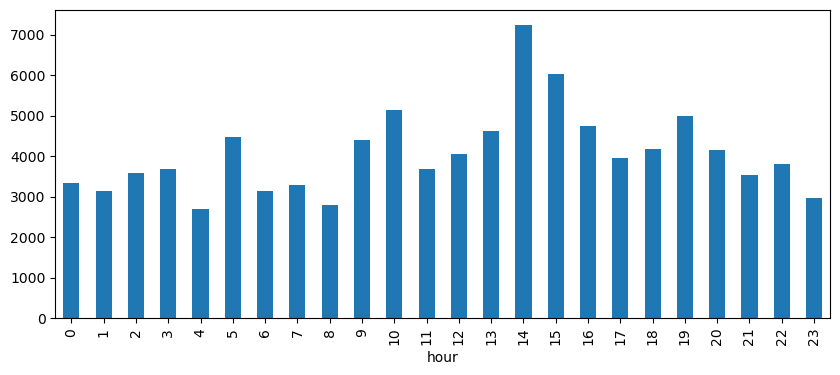

In [23]:
df["hour"] = df["noted_date"].dt.hour

df["hour"].value_counts().sort_index().plot(kind="bar", figsize=(10,4))


# Analyse des Températures Intérieur vs Extérieur

Dataset shape: (97606, 10)
Temperature range: 21.0°C to 51.0°C
Location distribution:
out/in
Out    77261
In     20345
Name: count, dtype: int64


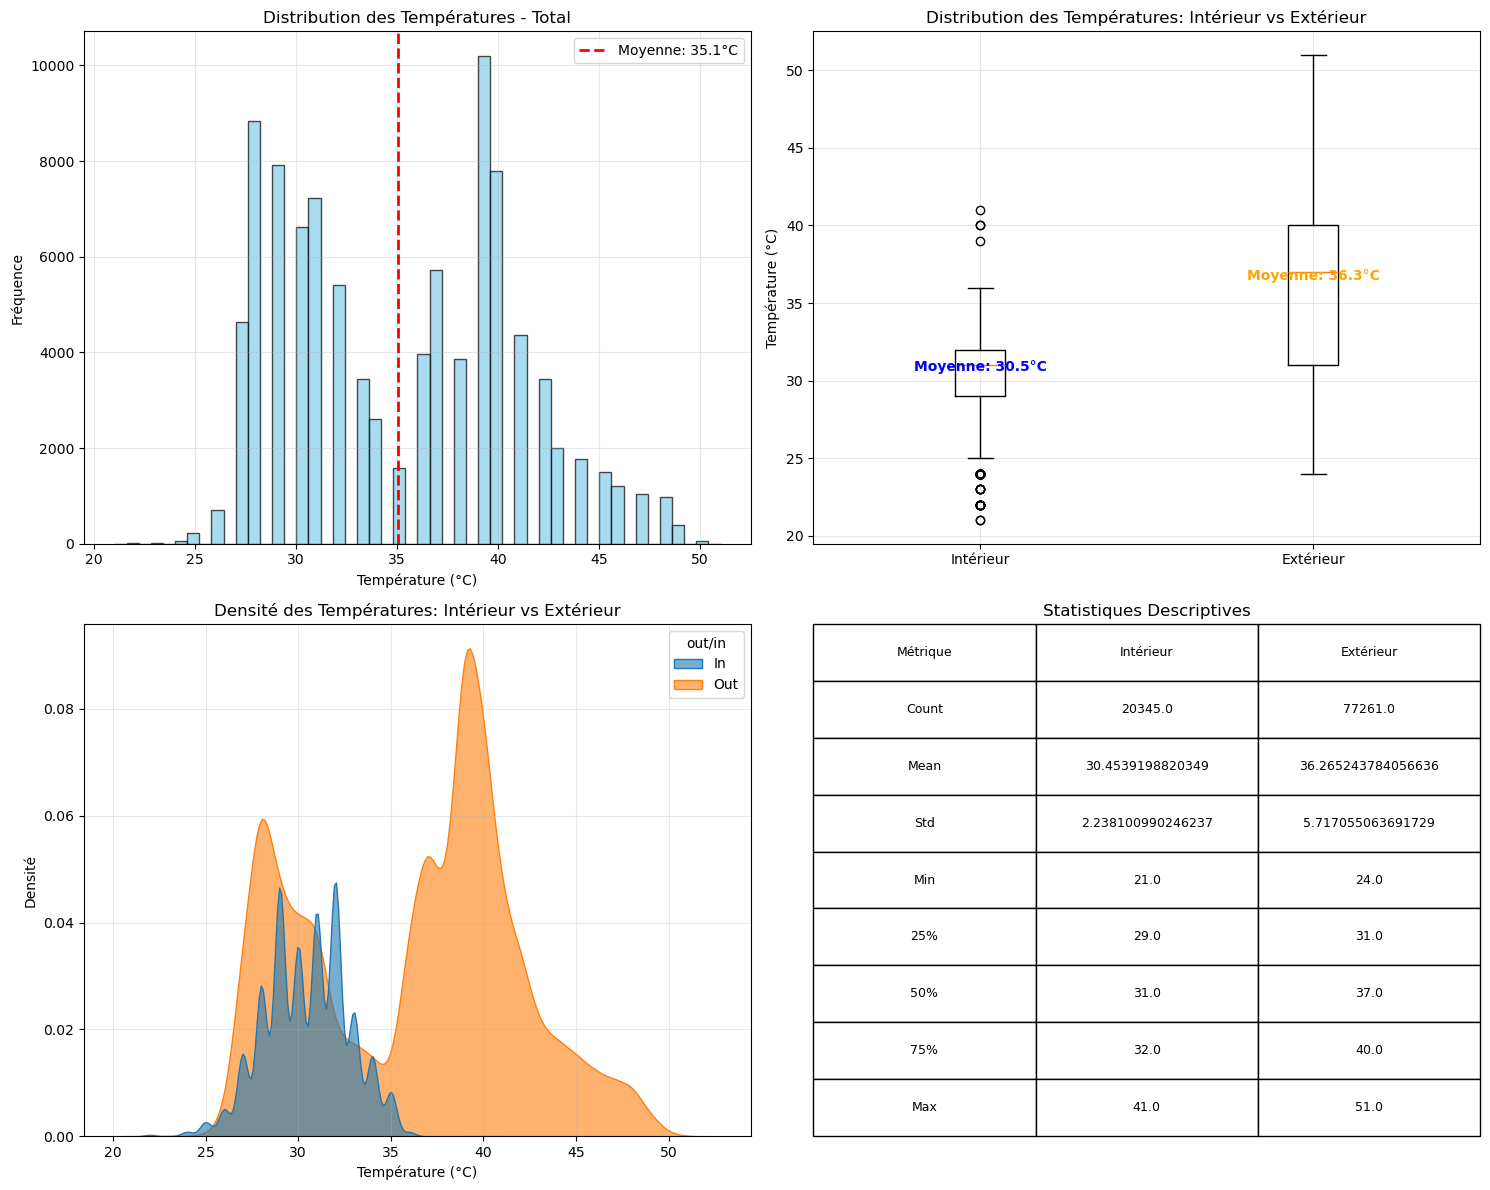


 ANALYSE COMPARATIVE:
 Température moyenne Intérieur: 30.45°C
 Température moyenne Extérieur: 36.27°C
 Différence moyenne: 5.81°C
 Écart-type Intérieur: 2.24°C
 Écart-type Extérieur: 5.72°C
  Plage Intérieur: 21.0°C - 41.0°C
 Plage Extérieur: 24.0°C - 51.0°C


In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")

# Convert date to datetime
df['noted_date'] = pd.to_datetime(df['noted_date'])

print(f"Dataset shape: {df.shape}")
print(f"Temperature range: {df['temp'].min():.1f}°C to {df['temp'].max():.1f}°C")
print(f"Location distribution:\n{df['out/in'].value_counts()}")

# Create the visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Distribution des températures (Overall)
axes[0, 0].hist(df['temp'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(df['temp'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Moyenne: {df["temp"].mean():.1f}°C')
axes[0, 0].set_xlabel('Température (°C)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des Températures - Total')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Comparaison In vs Out - Boxplot
in_temp = df[df['out/in'] == 'In']['temp']
out_temp = df[df['out/in'] == 'Out']['temp']

box_data = [in_temp, out_temp]
axes[0, 1].boxplot(box_data, labels=['Intérieur', 'Extérieur'])
axes[0, 1].set_ylabel('Température (°C)')
axes[0, 1].set_title('Distribution des Températures: Intérieur vs Extérieur')
axes[0, 1].grid(alpha=0.3)

# Add mean values to boxplot
axes[0, 1].text(1, in_temp.mean(), f'Moyenne: {in_temp.mean():.1f}°C', 
                ha='center', va='bottom', color='blue', fontweight='bold')
axes[0, 1].text(2, out_temp.mean(), f'Moyenne: {out_temp.mean():.1f}°C', 
                ha='center', va='bottom', color='orange', fontweight='bold')

# Plot 3: Comparaison In vs Out - Density Plot
sns.kdeplot(data=df, x='temp', hue='out/in', ax=axes[1, 0], fill=True, alpha=0.6)
axes[1, 0].set_xlabel('Température (°C)')
axes[1, 0].set_ylabel('Densité')
axes[1, 0].set_title('Densité des Températures: Intérieur vs Extérieur')
axes[1, 0].grid(alpha=0.3)

# Plot 4: Statistical Summary
stats_data = {
    'Métrique': ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max'],
    'Intérieur': [
        len(in_temp), in_temp.mean(), in_temp.std(), in_temp.min(),
        in_temp.quantile(0.25), in_temp.quantile(0.5), in_temp.quantile(0.75), in_temp.max()
    ],
    'Extérieur': [
        len(out_temp), out_temp.mean(), out_temp.std(), out_temp.min(),
        out_temp.quantile(0.25), out_temp.quantile(0.5), out_temp.quantile(0.75), out_temp.max()
    ]
}

stats_df = pd.DataFrame(stats_data)
axes[1, 1].axis('off')  # Turn off axis for table
table = axes[1, 1].table(cellText=stats_df.values,
                         colLabels=stats_df.columns,
                         cellLoc='center',
                         loc='center',
                         bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
axes[1, 1].set_title('Statistiques Descriptives')

plt.tight_layout()
plt.show()

# Additional insights
print(f"\n ANALYSE COMPARATIVE:")
print(f" Température moyenne Intérieur: {in_temp.mean():.2f}°C")
print(f" Température moyenne Extérieur: {out_temp.mean():.2f}°C")
print(f" Différence moyenne: {abs(in_temp.mean() - out_temp.mean()):.2f}°C")
print(f" Écart-type Intérieur: {in_temp.std():.2f}°C")
print(f" Écart-type Extérieur: {out_temp.std():.2f}°C")
print(f"  Plage Intérieur: {in_temp.min():.1f}°C - {in_temp.max():.1f}°C")
print(f" Plage Extérieur: {out_temp.min():.1f}°C - {out_temp.max():.1f}°C")

Période couverte: 2018-07-28 07:06:00 to 2018-12-08 09:30:00
Nombre total de points: 97606


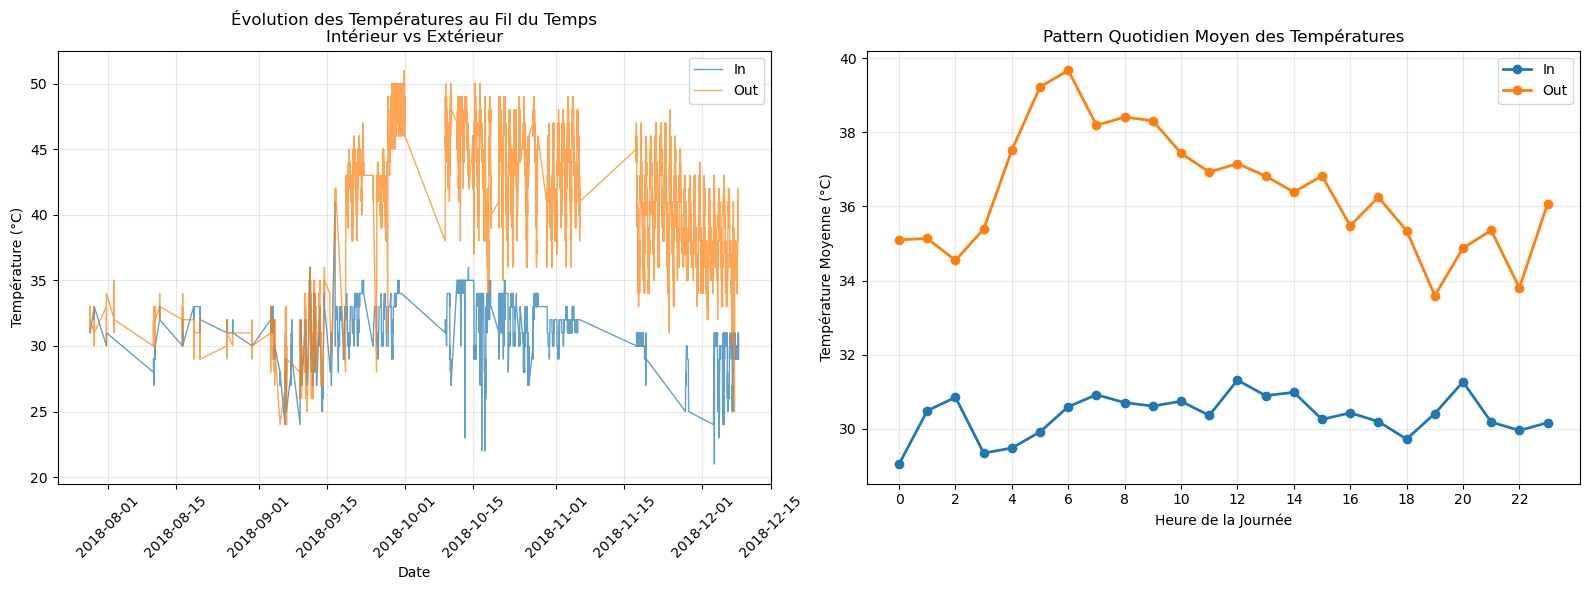


ANALYSE DES PATTERNS QUOTIDIENS:
Heure la plus chaude (Intérieur): 12h
Heure la plus froide (Intérieur): 0h
Amplitude quotidienne (Intérieur): 2.27°C
Amplitude quotidienne (Extérieur): 6.08°C


In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")

# Convert date to datetime and sort
df['noted_date'] = pd.to_datetime(df['noted_date'])
df = df.sort_values('noted_date')

print(f"Période couverte: {df['noted_date'].min()} to {df['noted_date'].max()}")
print(f"Nombre total de points: {len(df)}")

# Create the visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Température au fil du temps - Vue d'ensemble
for location in ['In', 'Out']:
    subset = df[df['out/in'] == location]
    axes[0].plot(subset['noted_date'], subset['temp'], 
                   label=location, alpha=0.7, linewidth=1, marker='', markersize=1)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Température (°C)')
axes[0].set_title('Évolution des Températures au Fil du Temps\nIntérieur vs Extérieur')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Variation quotidienne moyenne
df['hour'] = df['noted_date'].dt.hour
daily_pattern = df.groupby(['out/in', 'hour'])['temp'].mean().reset_index()

for location in ['In', 'Out']:
    subset = daily_pattern[daily_pattern['out/in'] == location]
    axes[1].plot(subset['hour'], subset['temp'], 
                   label=location, linewidth=2, marker='o')
axes[1].set_xlabel('Heure de la Journée')
axes[1].set_ylabel('Température Moyenne (°C)')
axes[1].set_title('Pattern Quotidien Moyen des Températures')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# Daily pattern insights
in_daily = daily_pattern[daily_pattern['out/in'] == 'In']
out_daily = daily_pattern[daily_pattern['out/in'] == 'Out']
print(f"\nANALYSE DES PATTERNS QUOTIDIENS:")
print(f"Heure la plus chaude (Intérieur): {in_daily.loc[in_daily['temp'].idxmax(), 'hour']}h")
print(f"Heure la plus froide (Intérieur): {in_daily.loc[in_daily['temp'].idxmin(), 'hour']}h")
print(f"Amplitude quotidienne (Intérieur): {in_daily['temp'].max() - in_daily['temp'].min():.2f}°C")
print(f"Amplitude quotidienne (Extérieur): {out_daily['temp'].max() - out_daily['temp'].min():.2f}°C")

# Extraire des caractéristiques temporelles

In [134]:
# Heure
df['hour'] = df['noted_date'].dt.hour

# Jour de la semaine
df['weekday'] = df['noted_date'].dt.weekday  # 0=Lundi, 6=Dimanche

# Week-end ou non
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Mois
df['month'] = df['noted_date'].dt.month

# Minute
df['minute'] = df['noted_date'].dt.minute


La colonne `is_weekend` indique simplement si la mesure a été prise le week-end (1) ou en semaine (0), permettant au modèle de capturer facilement les variations hebdomadaires de la température.


# Normaliser ou standardiser les valeurs?

In [64]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['temp_scaled'] = scaler.fit_transform(df[['temp']])


Pourquoi MinMaxScaler :

Plage connue et bornée (21–51°C)

LSTM/GRU convergent plus vite avec des valeurs entre 0 et 1.

StandardScaler (mean=0, std=1) peut aussi fonctionner, mais MinMax est plus simple pour ce type de données temporelles.

# Tester la stationnarité avec ADF

In [69]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['temp'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("La série est stationnaire")
else:
    print("La série n'est pas stationnaire")


ADF Statistic: -6.10085431873074
p-value: 9.843824620629996e-08
La série est stationnaire


# Vérifier random walk

                                    id  room_id/id        noted_date  temp  \
0  __export__.temp_log_196134_bd201015  Room Admin  08-12-2018 09:30    29   
1  __export__.temp_log_196131_7bca51bc  Room Admin  08-12-2018 09:30    29   
2  __export__.temp_log_196127_522915e3  Room Admin  08-12-2018 09:29    41   
3  __export__.temp_log_196128_be0919cf  Room Admin  08-12-2018 09:29    41   
4  __export__.temp_log_196126_d30b72fb  Room Admin  08-12-2018 09:29    31   

  out/in  
0     In  
1     In  
2    Out  
3    Out  
4     In  
Columns: Index(['id', 'room_id/id', 'noted_date', 'temp', 'out/in'], dtype='object')


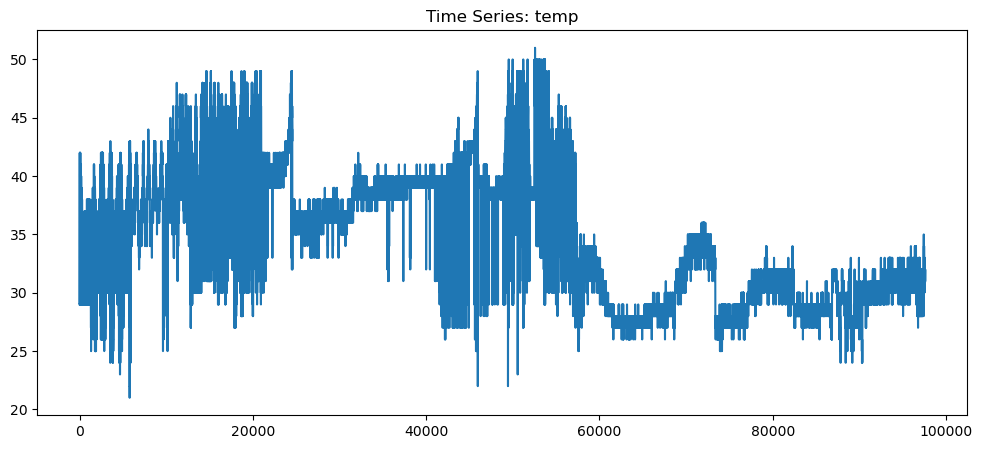

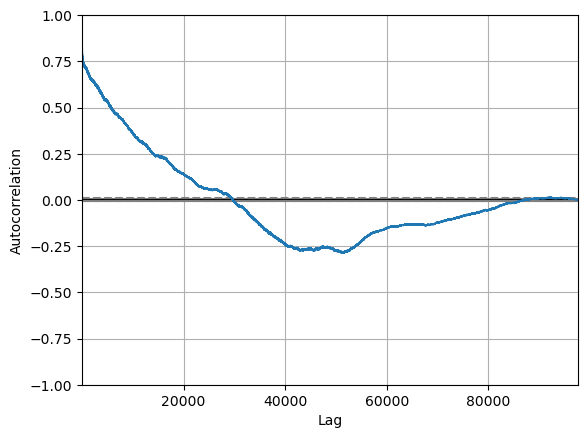

ADF Statistic: -6.063046692316383
p-value: 1.1997933298815761e-07
Critical Values: {'1%': -3.4304170460656684, '5%': -2.8615696333023712, '10%': -2.5667857727713517}
The series is stationary (not a random walk).


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.stattools import adfuller
# 1. Load CSV directly

csv_path = r"C:\Users\DELL\Downloads\deep-learning\IOT-temp.csv\IOT-temp.csv"
df = pd.read_csv(csv_path)

# 2. Inspect dataset

print(df.head())
print("Columns:", df.columns)

# 3. Select numeric column for time series

ts_col = df.select_dtypes(include=['float64', 'int64']).columns[0]
ts = df[ts_col]

# 4. Plot and ADF test

plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title(f"Time Series: {ts_col}")
plt.show()

autocorrelation_plot(ts)
plt.show()

# ADF test
adf_result = adfuller(ts)
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

if adf_result[1] > 0.05:
    print("The series is likely a random walk (non-stationary).")
else:
    print("The series is stationary (not a random walk).")


# Vérifier white noise

In [76]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Test de Ljung-Box sur les 20 premiers lags
ljung_box = acorr_ljungbox(df['temp'], lags=[20], return_df=True)
p_value = ljung_box['lb_pvalue'].values[0]

print("p-value du test Ljung-Box :", p_value)

if p_value < 0.05:
    print("La série n'est pas du white noise (corrélations significatives)")
else:
    print("La série peut être considérée comme white noise (aucune corrélation significative)")


p-value du test Ljung-Box : 0.0
La série n'est pas du white noise (corrélations significatives)


# Évolution de la température dans la salle IoT

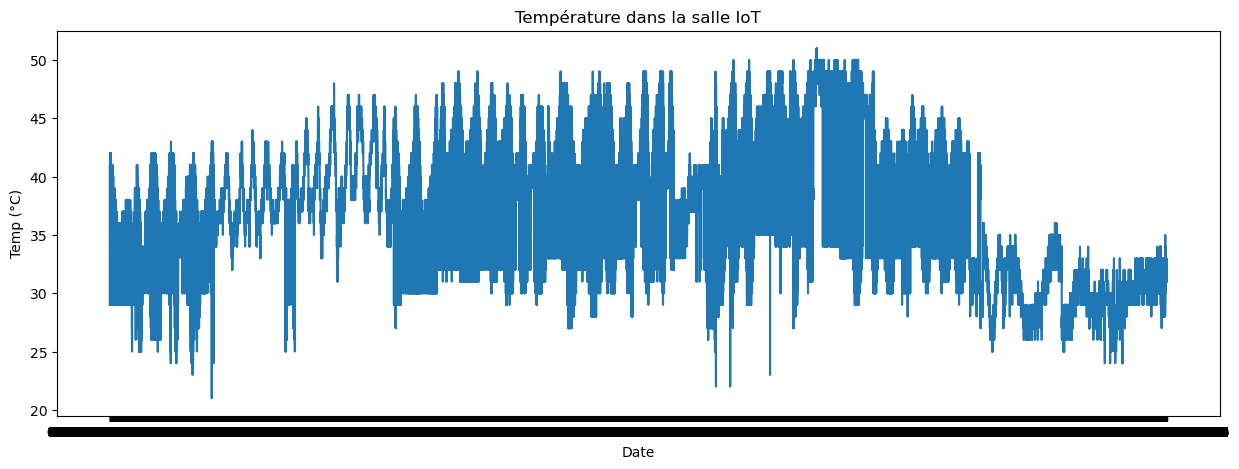

In [83]:
plt.figure(figsize=(15,5))
plt.plot(df['temp'])
plt.title("Température dans la salle IoT")
plt.xlabel("Date")
plt.ylabel("Temp (°C)")
plt.show()


# Time feature extraction

                                                      id  room_id/id  temp  \
timestamp                                                                    
2024-01-01 00:00:00  __export__.temp_log_196134_bd201015  Room Admin    29   
2024-01-01 00:01:00  __export__.temp_log_196131_7bca51bc  Room Admin    29   
2024-01-01 00:02:00  __export__.temp_log_196127_522915e3  Room Admin    41   
2024-01-01 00:03:00  __export__.temp_log_196128_be0919cf  Room Admin    41   
2024-01-01 00:04:00  __export__.temp_log_196126_d30b72fb  Room Admin    31   

                    out/in  hour  weekday  month  year  is_weekend  
timestamp                                                           
2024-01-01 00:00:00     In     0        0      1  2024           0  
2024-01-01 00:01:00     In     0        0      1  2024           0  
2024-01-01 00:02:00    Out     0        0      1  2024           0  
2024-01-01 00:03:00    Out     0        0      1  2024           0  
2024-01-01 00:04:00     In     0       

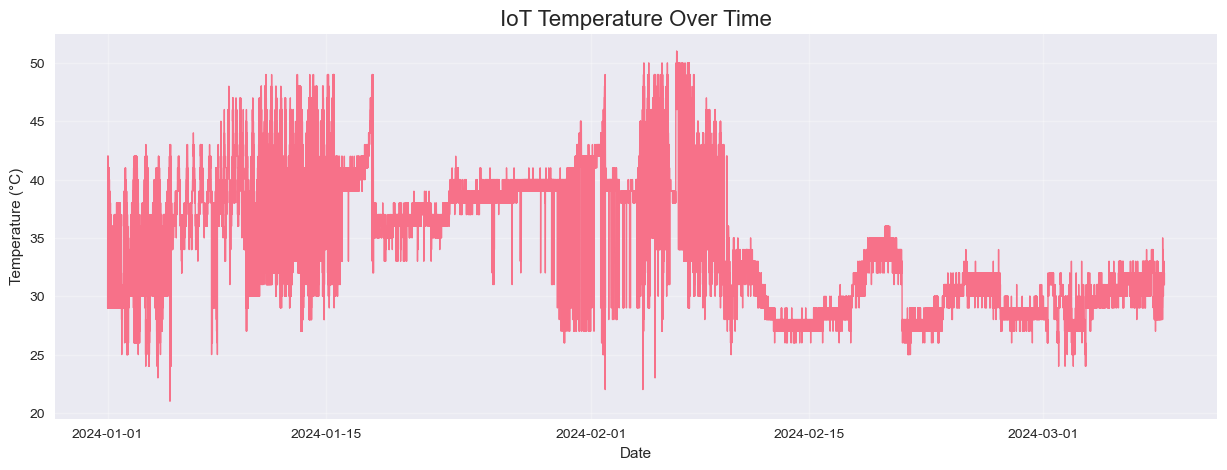

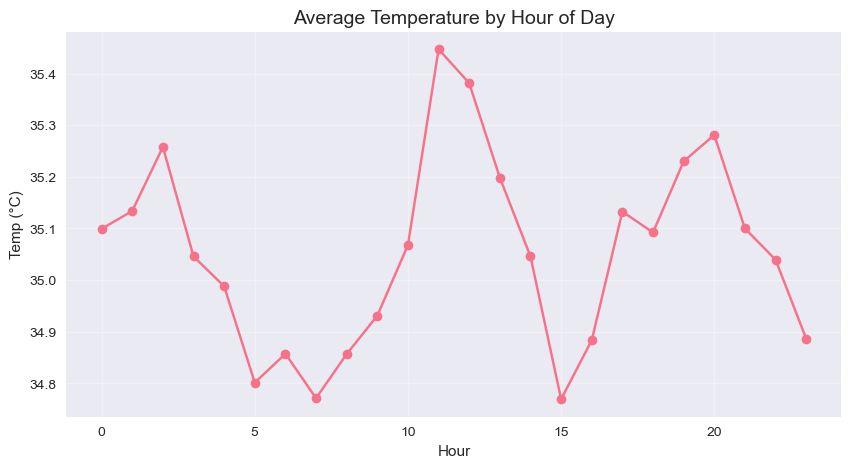

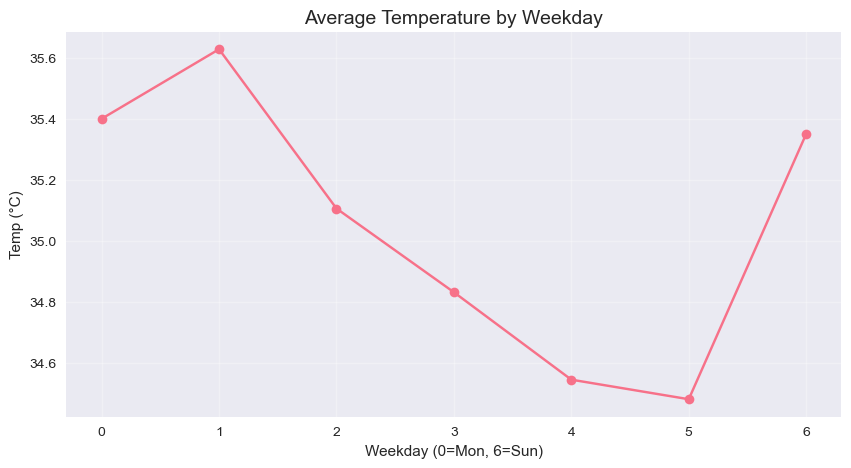

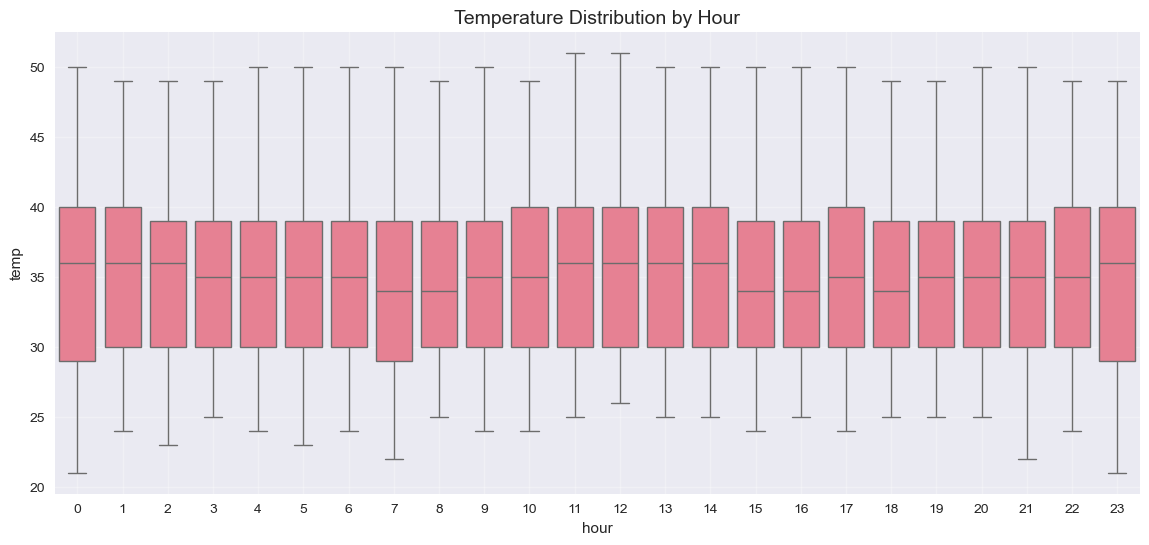

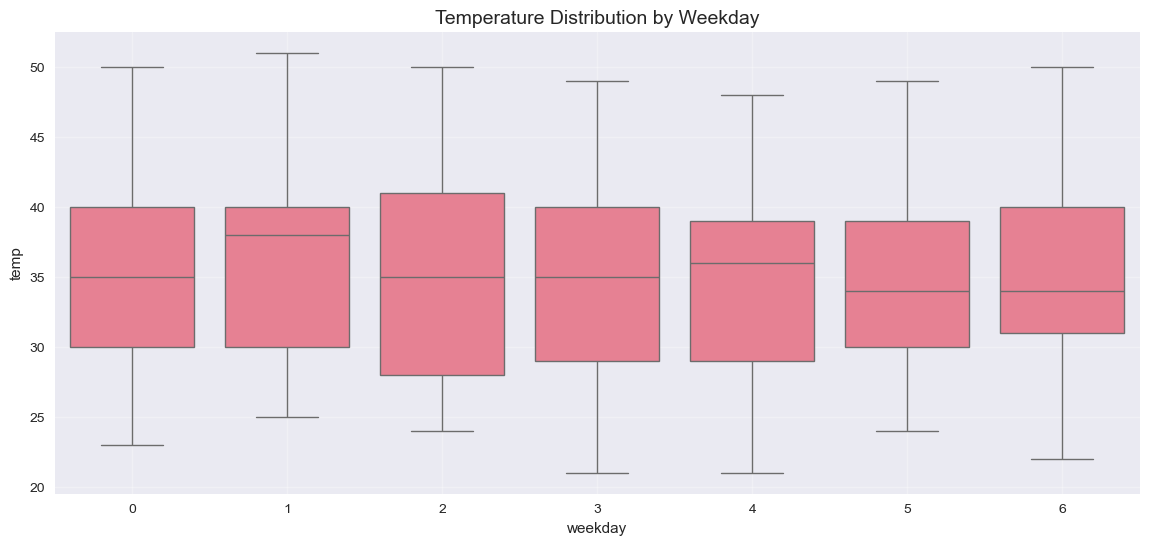

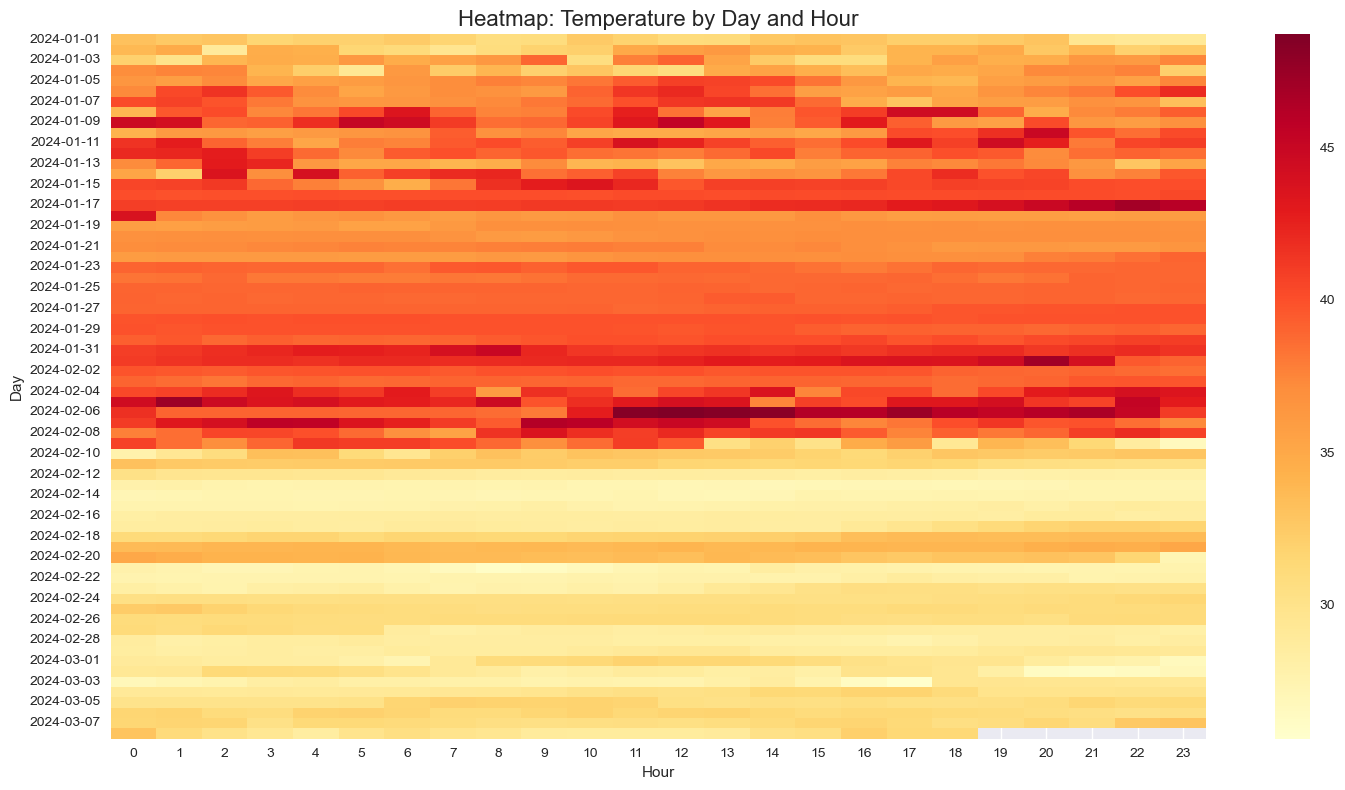


Hourly Temperature Statistics:
       mean   std  min  max
hour                       
0     35.10  5.71   21   50
1     35.13  5.75   24   49
2     35.26  5.73   23   49
3     35.05  5.61   25   49
4     34.99  5.69   24   50
5     34.80  5.61   23   50
6     34.86  5.62   24   50
7     34.77  5.62   22   50
8     34.86  5.63   25   49
9     34.93  5.76   24   50
10    35.07  5.79   24   49
11    35.45  5.93   25   51
12    35.38  5.96   26   51
13    35.20  5.73   25   50
14    35.05  5.50   25   50
15    34.77  5.41   24   50
16    34.88  5.50   25   50
17    35.13  5.71   24   50
18    35.09  5.57   25   49
19    35.23  5.64   25   49
20    35.28  5.84   25   50
21    35.10  5.78   22   50
22    35.04  5.75   24   49
23    34.89  5.86   21   49

Weekday Temperature Statistics:
          mean   std  min  max
weekday                       
0        35.40  5.52   23   50
1        35.63  5.96   25   51
2        35.11  6.61   24   50
3        34.83  6.14   21   49
4        34.54  5.21 

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Styling ---
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Assume: 1 measurement every minute
df['timestamp'] = pd.date_range(
    start='2024-01-01', 
    periods=len(df), 
    freq='1min'
)

df = df.set_index('timestamp')

# 1. Extract time features

df['hour'] = df.index.hour
df['weekday'] = df.index.weekday
df['month'] = df.index.month
df['year'] = df.index.year
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

print(df.head())

# 2. TIME SERIES PLOT

plt.figure(figsize=(15,5))
plt.plot(df.index, df['temp'], linewidth=1)
plt.title("IoT Temperature Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()


# 3. HOURLY SEASONALITY

plt.figure(figsize=(10,5))
df.groupby('hour')['temp'].mean().plot(marker='o')
plt.title("Average Temperature by Hour of Day", fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Temp (°C)")
plt.grid(True, alpha=0.3)
plt.show()


# 4. WEEKDAY SEASONALITY

plt.figure(figsize=(10,5))
df.groupby('weekday')['temp'].mean().plot(marker='o')
plt.title("Average Temperature by Weekday", fontsize=14)
plt.xlabel("Weekday (0=Mon, 6=Sun)")
plt.ylabel("Temp (°C)")
plt.grid(True, alpha=0.3)
plt.show()


# 5. Boxplot by Hour

plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='hour', y='temp')
sns.despine()
plt.title("Temperature Distribution by Hour", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 6. Boxplot by Weekday

plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='weekday', y='temp')
sns.despine()
plt.title("Temperature Distribution by Weekday", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 7. HEATMAP Day vs Hour

pivot = df.pivot_table(
    values='temp',
    index=df.index.date,
    columns=df.index.hour,
    aggfunc='mean'
)

plt.figure(figsize=(15,8))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title("Heatmap: Temperature by Day and Hour", fontsize=16)
plt.xlabel("Hour")
plt.ylabel("Day")
plt.tight_layout()
plt.show()

# 8. Summary statistics

print("\nHourly Temperature Statistics:")
print(df.groupby('hour')['temp'].agg(['mean','std','min','max']).round(2))

print("\nWeekday Temperature Statistics:")
print(df.groupby('weekday')['temp'].agg(['mean','std','min','max']).round(2))


# Analysis of Temperature Totals by Location (Indoor vs Outdoor)

In [95]:
import pandas as pd

# Load CSV
file_path = r"C:\Users\DELL\Downloads\deep-learning\IOT-temp.csv\IOT-temp.csv"
df = pd.read_csv(file_path)

# Display unique values in the out/in column
print("Unique values in out/in:", df['out/in'].unique())

# Sum of temp for each unique value in out/in
result = df.groupby('out/in')['temp'].sum()

print("\nSum of temp for each unique value in out/in:")
print(result)


Unique values in out/in: ['In' 'Out']

Sum of temp for each unique value in out/in:
out/in
In      619585
Out    2801889
Name: temp, dtype: int64


# Minimum and Maximum Temperature by Location (Indoor vs Outdoor)

In [97]:
import pandas as pd

# Load CSV
file_path = r"C:\Users\DELL\Downloads\deep-learning\IOT-temp.csv\IOT-temp.csv"
df = pd.read_csv(file_path)

# Group by out/in and calculate max + min temp
result = df.groupby('out/in')['temp'].agg(['min', 'max'])

print("Minimum and Maximum temperature for INS and OUTS:")
print(result)


Minimum and Maximum temperature for INS and OUTS:
        min  max
out/in          
In       21   41
Out      24   51


# Detection of Temperature Outliers

In [101]:
Q1 = df["temp"].quantile(0.25)
Q3 = df["temp"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["temp"] < lower) | (df["temp"] > upper)]
print(outliers)


Empty DataFrame
Columns: [id, room_id/id, noted_date, temp, out/in]
Index: []


# Visualization of Temperature Trends and Distribution

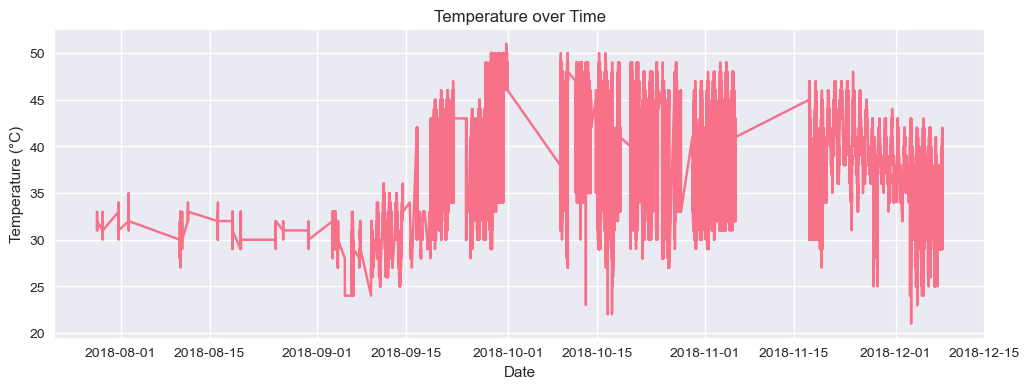

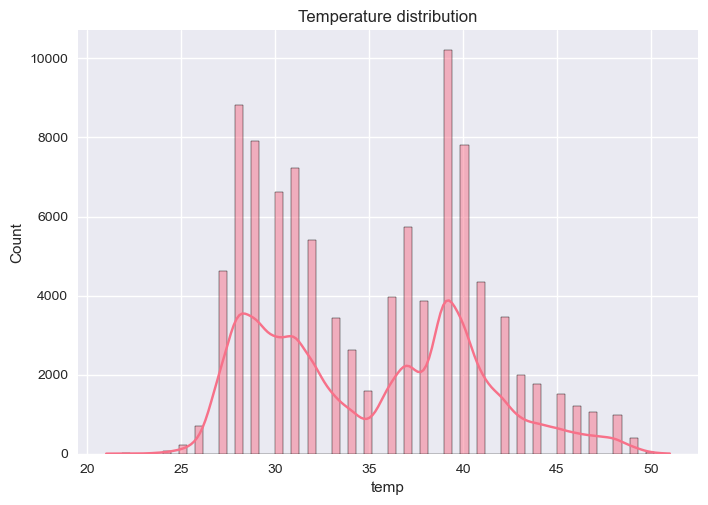

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Temperature over time
plt.figure(figsize=(12,4))
plt.plot(df["noted_date"], df["temp"])
plt.title("Temperature over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()



# 3. Histogram
sns.histplot(df["temp"], kde=True)
plt.title("Temperature distribution")
plt.show()


# Temperature Trends by Time Period and Location

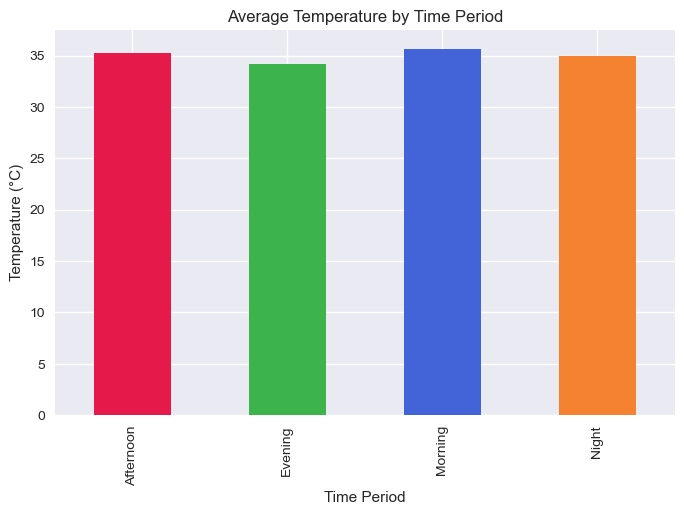

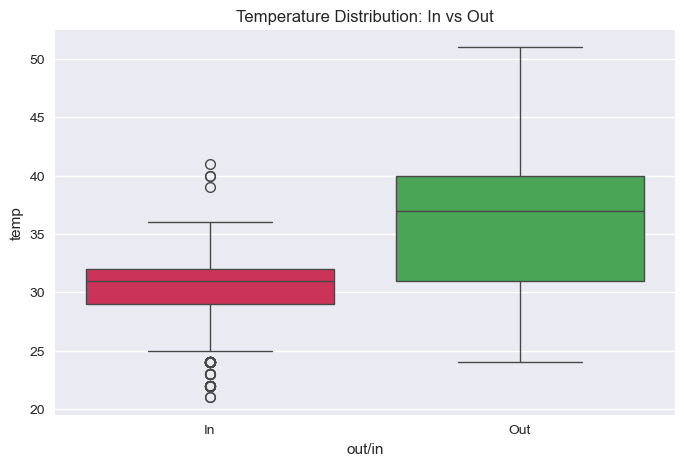

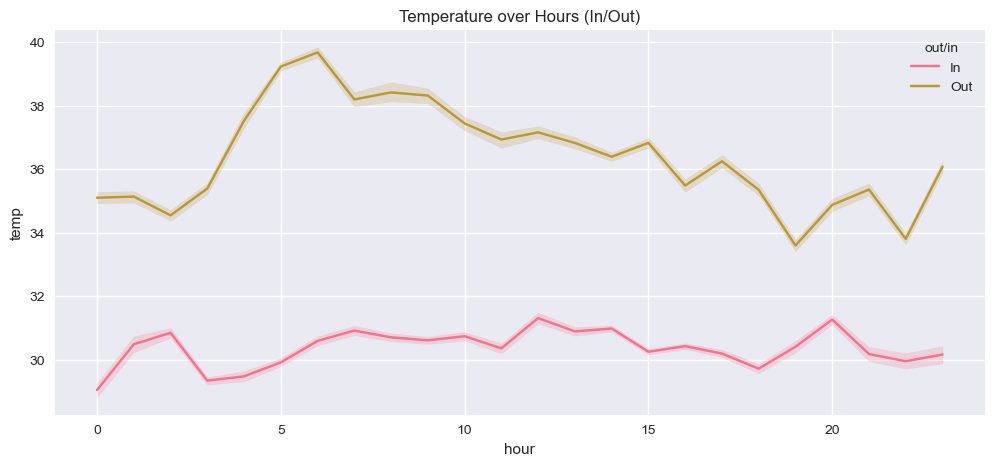

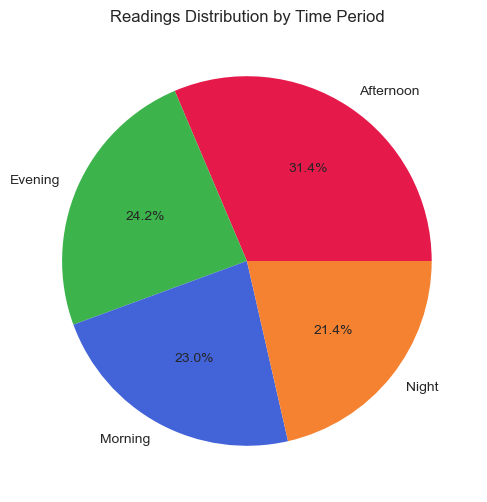

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure your date is datetime and you have hour
df['noted_date'] = pd.to_datetime(df['noted_date'], dayfirst=True)
df['hour'] = df['noted_date'].dt.hour

# ------------------------
# 1. Classify time period
# ------------------------
def classify_time_period(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['hour'].apply(classify_time_period)

# 2. Visualizations

# 2a: Average temperature by time period
temp_by_period = df.groupby('time_period')['temp'].mean()

plt.figure(figsize=(8,5))
temp_by_period.plot(kind='bar', color=['#e6194B','#3cb44b','#4363d8','#f58231'])
plt.title("Average Temperature by Time Period")
plt.ylabel("Temperature (°C)")
plt.xlabel("Time Period")
plt.show()

# 2b: Temperature distribution by In/Out
plt.figure(figsize=(8,5))
sns.boxplot(x='out/in', y='temp', data=df, hue='out/in', palette=['#e6194B','#3cb44b'], dodge=False, legend=False)

plt.title("Temperature Distribution: In vs Out")
plt.show()

# 2c: Temperature over hours
plt.figure(figsize=(12,5))
sns.lineplot(x='hour', y='temp', hue='out/in', data=df)
plt.title("Temperature over Hours (In/Out)")
plt.show()

# 2d: Pie chart of readings per time period
time_counts = df['time_period'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(time_counts, labels=time_counts.index, autopct='%1.1f%%', 
        colors=['#e6194B', '#3cb44b', '#4363d8', '#f58231'])
plt.title("Readings Distribution by Time Period")
plt.show()


<Axes: xlabel='temp'>

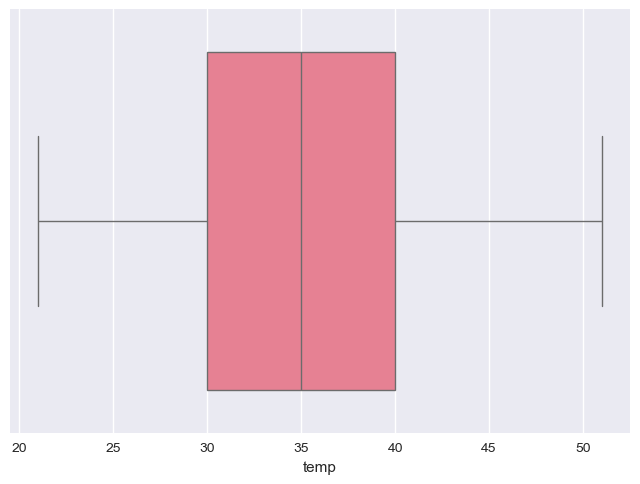

In [111]:
sns.boxplot(x=df["temp"])


In [115]:
df["hour"] = df["noted_date"].dt.hour
df["weekday"] = df["noted_date"].dt.weekday
df["month"] = df["noted_date"].dt.month

df["out_in_num"] = df["out/in"].map({"In": 0, "Out": 1})


In [117]:
output_path = r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv"
df.to_csv(output_path, index=False)

print("Nouveau dataset enregistré :", output_path)


Nouveau dataset enregistré : C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv


# Correlation Heatmap

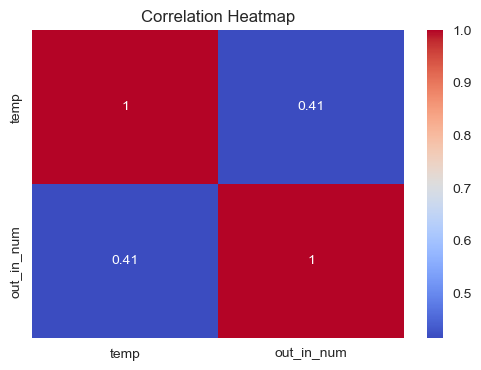

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


The temperature and in/out category show a moderate positive correlation (0.41), meaning the indoor/outdoor location moderately influences the temperature values.

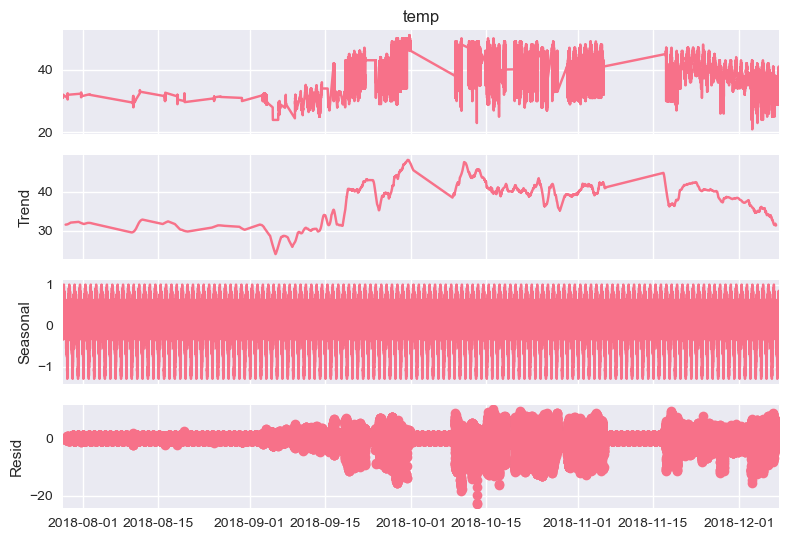

In [135]:
df2 = df.set_index("noted_date").sort_index()

# resample every 2 minutes (mean temp)
df_resampled = df2["temp"].resample("2min").mean().interpolate()

from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_resampled, model="additive", period=720) 
decomp.plot()
plt.show()


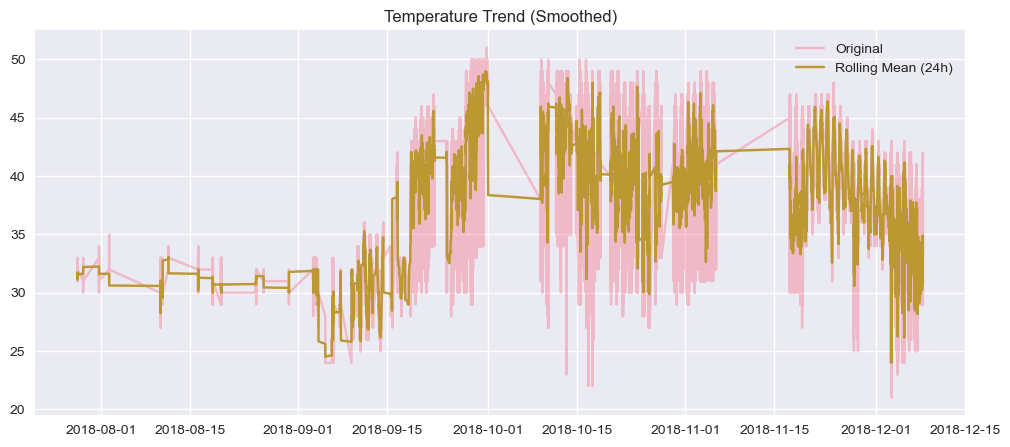

In [139]:
df["rolling"] = df["temp"].rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(df["noted_date"], df["temp"], alpha=0.4, label="Original")
plt.plot(df["noted_date"], df["rolling"], label="Rolling Mean (24h)")
plt.legend()
plt.title("Temperature Trend (Smoothed)")
plt.show()


# Feature engineering

In [128]:
import numpy as np

# -------------- ROOM NAME ENCODER --------------
ROOM_ID_MAP = {
    "Room Admin": 1,
    "Room A": 2,
    "Room B": 3,
    "Room C": 4,
    "Hall": 5
}

def encode_room(room_name):
    return ROOM_ID_MAP.get(room_name.strip(), 0)

# ------------ TIME FEATURES ------------
df['hour'] = df['noted_date'].dt.hour
df['day_of_week'] = df['noted_date'].dt.dayofweek
df['month'] = df['noted_date'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

def period(h):
    if 6 <= h < 12: return "Morning"
    if 12 <= h < 18: return "Afternoon"
    if 18 <= h < 24: return "Evening"
    return "Night"

df['period'] = df['hour'].apply(period)

# ------------ LAG FEATURES ------------
df['temp_lag1'] = df['temp'].shift(1)
df['temp_lag2'] = df['temp'].shift(2)
df['temp_lag3'] = df['temp'].shift(3)

# ------------ ROLLING FEATURES ------------
df['temp_roll_mean_3'] = df['temp'].rolling(3).mean()
df['temp_roll_std_3'] = df['temp'].rolling(3).std()

# ------------ CYCLICAL ENCODING ------------
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# ------------ ROOM ID ENCODING ------------
df['room_id_int'] = df['room_id/id'].apply(encode_room)


In [130]:
df.head()

,id,room_id/id,noted_date,temp,out/in,hour,weekday,month,out_in_num,day_of_week,...,is_weekend,period,temp_lag1,temp_lag2,temp_lag3,temp_roll_mean_3,temp_roll_std_3,hour_sin,hour_cos,room_id_int
0,__export__.temp_log_133741_32958703,Room Admin,2018-07-28 07:06:00,31,In,7,5,7,0,5,...,1,Morning,NaN,NaN,NaN,NaN,NaN,0.965926,-0.258819,1
1,__export__.temp_log_123297_4d8e690b,Room Admin,2018-07-28 07:06:00,31,In,7,5,7,0,5,...,1,Morning,31.0,NaN,NaN,NaN,NaN,0.965926,-0.258819,1
2,__export__.temp_log_100386_84093a68,Room Admin,2018-07-28 07:06:00,31,In,7,5,7,0,5,...,1,Morning,31.0,31.0,NaN,31.0,0.0,0.965926,-0.258819,1
3,__export__.temp_log_118398_6ebe504d,Room Admin,2018-07-28 07:07:00,31,In,7,5,7,0,5,...,1,Morning,31.0,31.0,31.0,31.0,0.0,0.965926,-0.258819,1
4,__export__.temp_log_144221_a4f20688,Room Admin,2018-07-28 07:07:00,31,In,7,5,7,0,5,...,1,Morning,31.0,31.0,31.0,31.0,0.0,0.965926,-0.258819,1


# Train/Test split

In [164]:
import pandas as pd

# Load CSV
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")

# Ensure noted_date is datetime (ISO format, no dayfirst)
df['noted_date'] = pd.to_datetime(df['noted_date'])

# Sort by date
df = df.sort_values('noted_date').reset_index(drop=True)

# Define split ratio
train_ratio = 0.8
split_index = int(len(df) * train_ratio)

# Chronological split
train = df.iloc[:split_index].dropna() 
test  = df.iloc[split_index:].dropna()

# Features and target
X_train = train.drop(columns=['temp', 'id', 'room_id/id', 'noted_date', 'out/in'])
y_train = train['temp']

X_test = test.drop(columns=['temp', 'id', 'room_id/id', 'noted_date', 'out/in'])
y_test = test['temp']

# Print shapes
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train rows: {len(train)}, Test rows: {len(test)}")


Train shape: (78084, 5), Test shape: (19522, 5)
Train rows: 78084, Test rows: 19522


In [171]:
from sklearn.model_selection import TimeSeriesSplit

# Make X and y from your full dataframe (after feature engineering)
X = df.drop(columns=['temp', 'id', 'room_id/id', 'noted_date', 'out/in'])
y = df['temp']

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Loop through the folds
for fold, (train_index, test_index) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    print(f"Fold {fold}:")
    print(f"  Train rows: {len(train_index)}, Test rows: {len(test_index)}")
    print(f"  Train starts at: {X_train.index[0]}, ends at: {X_train.index[-1]}")
    print(f"  Test starts at: {X_test.index[0]}, ends at: {X_test.index[-1]}\n")


Fold 1:
  Train rows: 16271, Test rows: 16267
  Train starts at: 0, ends at: 16270
  Test starts at: 16271, ends at: 32537

Fold 2:
  Train rows: 32538, Test rows: 16267
  Train starts at: 0, ends at: 32537
  Test starts at: 32538, ends at: 48804

Fold 3:
  Train rows: 48805, Test rows: 16267
  Train starts at: 0, ends at: 48804
  Test starts at: 48805, ends at: 65071

Fold 4:
  Train rows: 65072, Test rows: 16267
  Train starts at: 0, ends at: 65071
  Test starts at: 65072, ends at: 81338

Fold 5:
  Train rows: 81339, Test rows: 16267
  Train starts at: 0, ends at: 81338
  Test starts at: 81339, ends at: 97605



# Machine Learning Models:

# Baseline Model Comparison: Persistence vs Median Forecasting for Temperature Prediction

Persistence - RMSE: 3.357, MAE: 1.308
Median      - RMSE: 3.020, MAE: 1.082


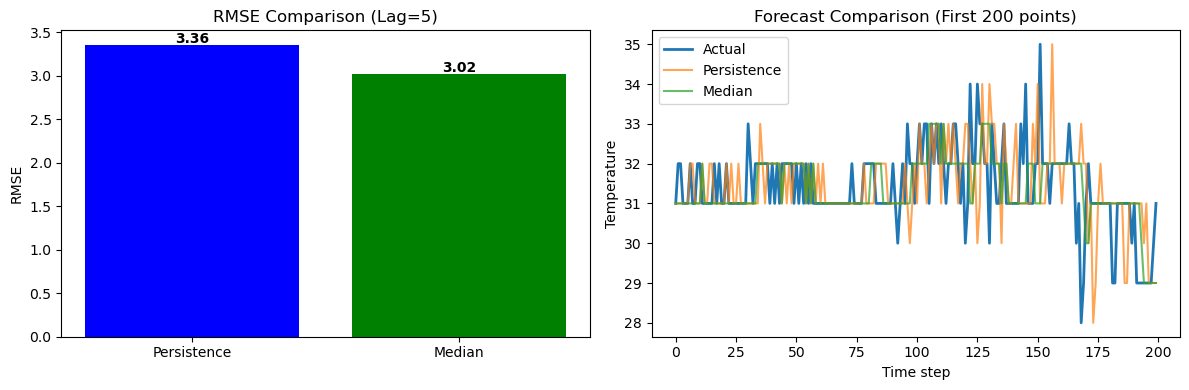

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load and prepare data
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")
df['noted_date'] = pd.to_datetime(df['noted_date'])
df = df.sort_values('noted_date').reset_index(drop=True)

# Set lag
lag = 5

# True values
y_true = df['temp'].iloc[lag:].values

# Persistence forecast
y_pred_persist = df['temp'].shift(lag).iloc[lag:].values

# Median forecast (FIXED - no data leakage)
y_pred_median = df['temp'].rolling(window=lag, min_periods=1).median().shift(1).iloc[lag:].values

# Compute metrics
rmse_persist = np.sqrt(mean_squared_error(y_true, y_pred_persist))
rmse_median = np.sqrt(mean_squared_error(y_true, y_pred_median))

mae_persist = mean_absolute_error(y_true, y_pred_persist)
mae_median = mean_absolute_error(y_true, y_pred_median)

print(f"Persistence - RMSE: {rmse_persist:.3f}, MAE: {mae_persist:.3f}")
print(f"Median      - RMSE: {rmse_median:.3f}, MAE: {mae_median:.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RMSE comparison
metrics_df = pd.DataFrame({
    "Model": ["Persistence", "Median"],
    "RMSE": [rmse_persist, rmse_median],
    "MAE": [mae_persist, mae_median]
})

axes[0].bar(metrics_df["Model"], metrics_df["RMSE"], color=["blue", "green"])
axes[0].set_ylabel("RMSE")
axes[0].set_title(f"RMSE Comparison (Lag={lag})")
for i, v in enumerate(metrics_df["RMSE"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

# Time series plot
n_points = min(200, len(y_true))
axes[1].plot(y_true[:n_points], label="Actual", linewidth=2)
axes[1].plot(y_pred_persist[:n_points], label="Persistence", alpha=0.7)
axes[1].plot(y_pred_median[:n_points], label="Median", alpha=0.7)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Temperature")
axes[1].set_title(f"Forecast Comparison (First {n_points} points)")
axes[1].legend()

plt.tight_layout()
plt.show()

The Median forecast (green, RMSE=3.02) outperforms Persistence (blue, RMSE=3.36) by smoothing out short-term temperature fluctuations, as shown in the right plot where the green line tracks the actual temperature changes more closely than the orange persistence line.

# Linear Regression model

Dataset Info:
                                    id  room_id/id          noted_date  temp  \
0  __export__.temp_log_133741_32958703  Room Admin 2018-07-28 07:06:00    31   
1  __export__.temp_log_123297_4d8e690b  Room Admin 2018-07-28 07:06:00    31   
2  __export__.temp_log_100386_84093a68  Room Admin 2018-07-28 07:06:00    31   
3  __export__.temp_log_118398_6ebe504d  Room Admin 2018-07-28 07:07:00    31   
4  __export__.temp_log_144221_a4f20688  Room Admin 2018-07-28 07:07:00    31   

  out/in  hour time_period  weekday  month  out_in_num  
0     In     7     Morning        5      7           0  
1     In     7     Morning        5      7           0  
2     In     7     Morning        5      7           0  
3     In     7     Morning        5      7           0  
4     In     7     Morning        5      7           0  

Shape: (97606, 10)

Columns: ['id', 'room_id/id', 'noted_date', 'temp', 'out/in', 'hour', 'time_period', 'weekday', 'month', 'out_in_num']

Missing values:
id    

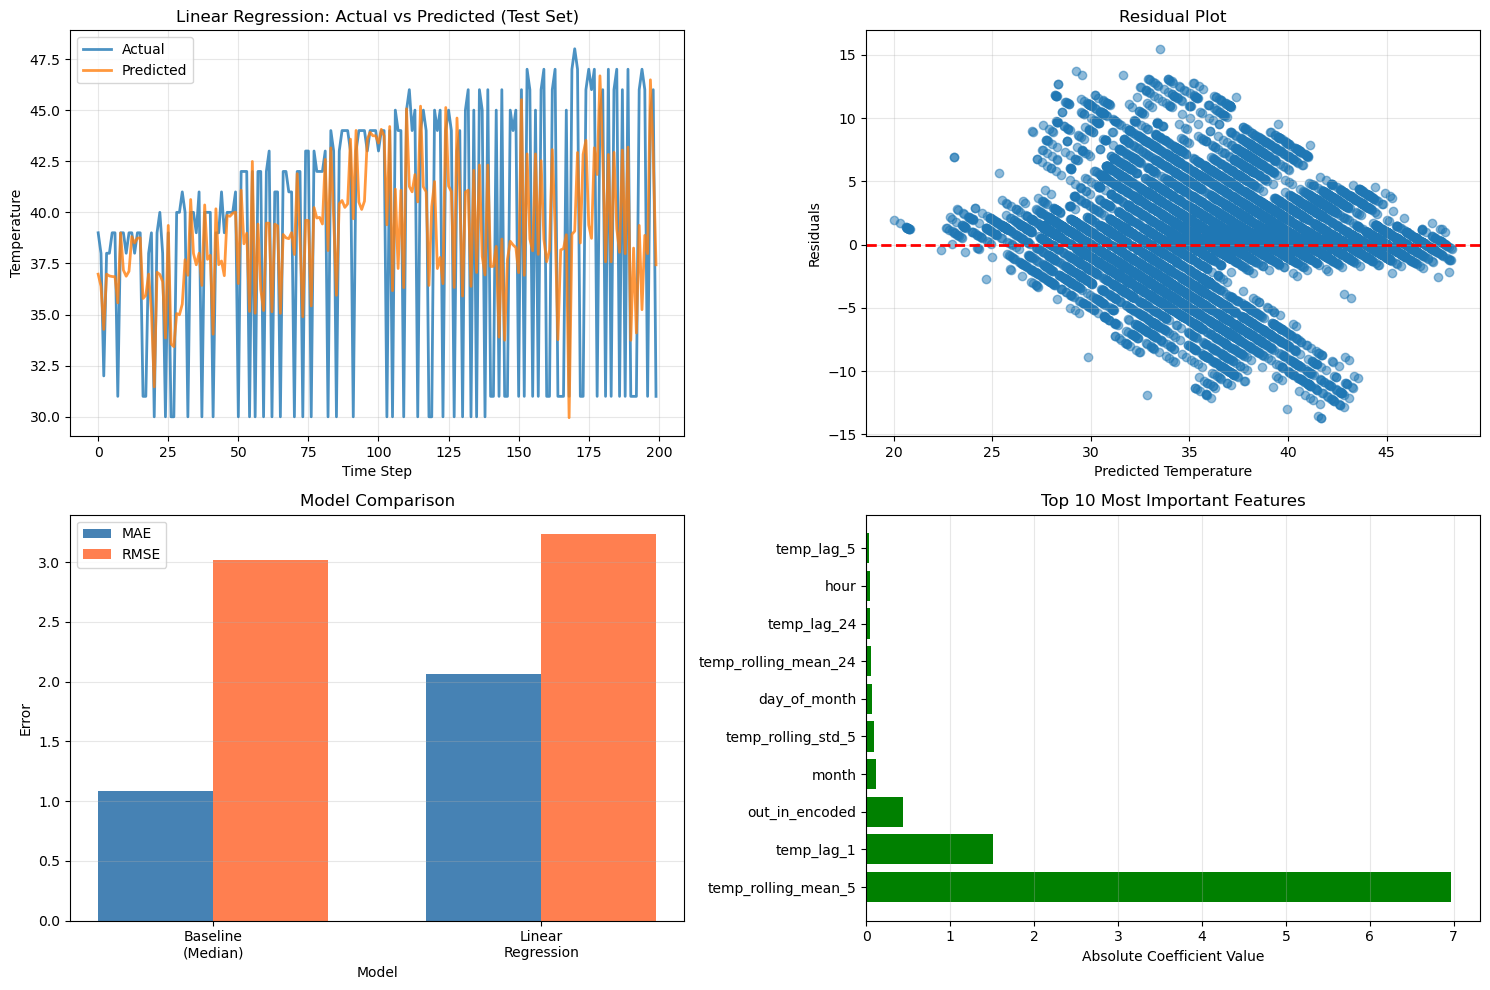

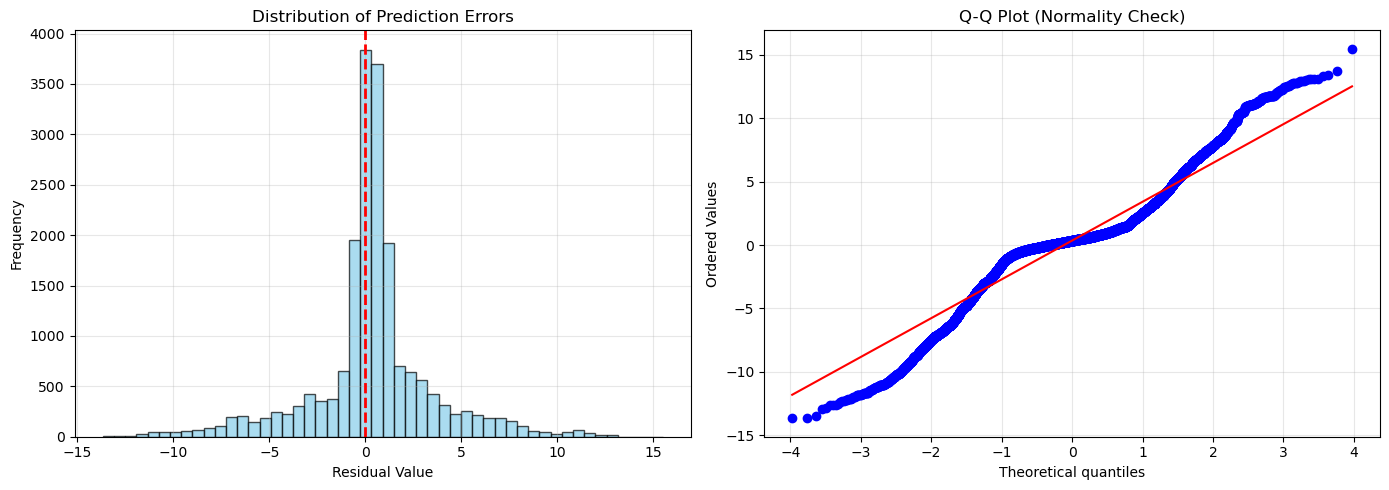


✓ Linear Regression model completed successfully!


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")

# Convert date to datetime
df['noted_date'] = pd.to_datetime(df['noted_date'])

# Sort by date
df = df.sort_values('noted_date').reset_index(drop=True)

print("Dataset Info:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Feature Engineering for Time Series

# Extract time features
df['hour'] = df['noted_date'].dt.hour
df['day_of_week'] = df['noted_date'].dt.dayofweek
df['day_of_month'] = df['noted_date'].dt.day
df['month'] = df['noted_date'].dt.month

# Create lag features (past temperature values)
for lag in [1, 5, 10, 24]:
    df[f'temp_lag_{lag}'] = df['temp'].shift(lag)

# Rolling statistics (moving average and std)
df['temp_rolling_mean_5'] = df['temp'].rolling(window=5).mean()
df['temp_rolling_std_5'] = df['temp'].rolling(window=5).std()
df['temp_rolling_mean_24'] = df['temp'].rolling(window=24).mean()

# Encode categorical variable 'out/in' if it exists
if 'out/in' in df.columns:
    df['out_in_encoded'] = df['out/in'].map({'Out': 0, 'In': 1})
    # If values are different, adjust accordingly
    if df['out_in_encoded'].isnull().any():
        # Use one-hot encoding as backup
        df = pd.get_dummies(df, columns=['out/in'], prefix='location', drop_first=True)

# Drop rows with NaN (created by lag and rolling features)
df_clean = df.dropna().reset_index(drop=True)

print(f"\nAfter feature engineering: {df_clean.shape}")

# Prepare Features and Target

# Select features for regression
feature_cols = [
    'temp_lag_1', 'temp_lag_5', 'temp_lag_10', 'temp_lag_24',
    'temp_rolling_mean_5', 'temp_rolling_std_5', 'temp_rolling_mean_24',
    'hour', 'day_of_week', 'day_of_month', 'month'
]

# Add room_id if it varies
if df_clean['room_id/id'].nunique() > 1:
    feature_cols.append('room_id/id')

# Add encoded out/in feature if it exists
if 'out_in_encoded' in df_clean.columns:
    feature_cols.append('out_in_encoded')
elif any('location_' in col for col in df_clean.columns):
    feature_cols.extend([col for col in df_clean.columns if col.startswith('location_')])

# Filter only existing columns
feature_cols = [col for col in feature_cols if col in df_clean.columns]

X = df_clean[feature_cols].values
y = df_clean['temp'].values

print(f"\nFeatures used: {feature_cols}")

# Train/Test Split (Time Series - No Shuffle)

# Use 80% for training, 20% for testing (chronological split)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression Model

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make Predictions

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Evaluate Model


# Training metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)


print("LINEAR REGRESSION RESULTS")
print(f"\nTRAIN SET:")
print(f"  RMSE: {train_rmse:.3f}")
print(f"  MAE:  {train_mae:.3f}")
print(f"  R²:   {train_r2:.3f}")

print(f"\nTEST SET:")
print(f"  RMSE: {test_rmse:.3f}")
print(f"  MAE:  {test_mae:.3f}")
print(f"  R²:   {test_r2:.3f}")

print("COMPARISON WITH BASELINES")
print(f"Baseline Median MAE:     1.082")
print(f"Linear Regression MAE:   {test_mae:.3f}")
improvement = ((1.082 - test_mae) / 1.082 * 100)
if improvement > 0:
    print(f"Improvement:             {improvement:.1f}% better ✓")
else:
    print(f"Performance:             {abs(improvement):.1f}% worse ✗")

# Feature Importance


print("FEATURE IMPORTANCE (Coefficients)")
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(feature_importance.to_string(index=False))

# Visualizations

# Calculate residuals first
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Actual vs Predicted (Test Set - First 200 points)
n_points = min(200, len(y_test))
axes[0, 0].plot(y_test[:n_points], label='Actual', linewidth=2, alpha=0.8)
axes[0, 0].plot(y_test_pred[:n_points], label='Predicted', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Time Step')
axes[0, 0].set_ylabel('Temperature')
axes[0, 0].set_title(f'Linear Regression: Actual vs Predicted (Test Set)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residuals
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Temperature')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Metrics Comparison
models = ['Baseline\n(Median)', 'Linear\nRegression']
mae_values = [1.082, test_mae]
rmse_values = [3.020, test_rmse]

x_pos = np.arange(len(models))
width = 0.35

axes[1, 0].bar(x_pos - width/2, mae_values, width, label='MAE', color='steelblue')
axes[1, 0].bar(x_pos + width/2, rmse_values, width, label='RMSE', color='coral')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('Error')
axes[1, 0].set_title('Model Comparison')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Importance
top_features = feature_importance.head(10)
axes[1, 1].barh(top_features['Feature'], abs(top_features['Coefficient']), color='green')
axes[1, 1].set_xlabel('Absolute Coefficient Value')
axes[1, 1].set_title('Top 10 Most Important Features')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Error Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Errors')
axes[0].grid(alpha=0.3)

# Q-Q plot (checking normality of residuals)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Linear Regression model completed successfully!")

Linear Regression model is severely overfitting: it performs excellently on training data (MAE=0.714) but catastrophically fails on test data (MAE=2.063), performing 90.6% worse than the simple baseline, which indicates the model learned noise rather than true patterns and cannot generalize to unseen data.

# XGBoost model

XGBOOST FOR IOT TEMPERATURE FORECASTING
Dataset shape: (97606, 10)
Date range: 2018-07-28 07:06:00 to 2018-12-08 09:30:00
Temperature range: 21.00°C to 51.00°C
FEATURE ENGINEERING

Categorical columns found: ['time_period']
Applied one-hot encoding to: ['time_period']
Features created: 38 features (excluding id, date, temp)
Dataset after cleaning: (97558, 41)

Total features used: 36
Feature list (first 10): ['hour', 'weekday', 'month', 'out_in_num', 'day_of_week', 'day_of_month', 'day_of_year', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3']

Data types check:
Removing non-numeric columns...

Final feature count: 33
X shape: (97558, 33), y shape: (97558,)
DATA SPLIT
Training samples: 78046 (80.0%)
Testing samples:  19512 (20.0%)

APPLYING SCALING
✓ Features scaled using StandardScaler

TRAINING XGBOOST MODEL
Training in progress...
Training completed!

SAVING MODEL AND SCALER
✓ Model saved to: C:\Users\DELL\Downloads\DL2\backend1\models1\xgboost_temp_model.pkl
✓ Scaler saved to: C:\Users\DE

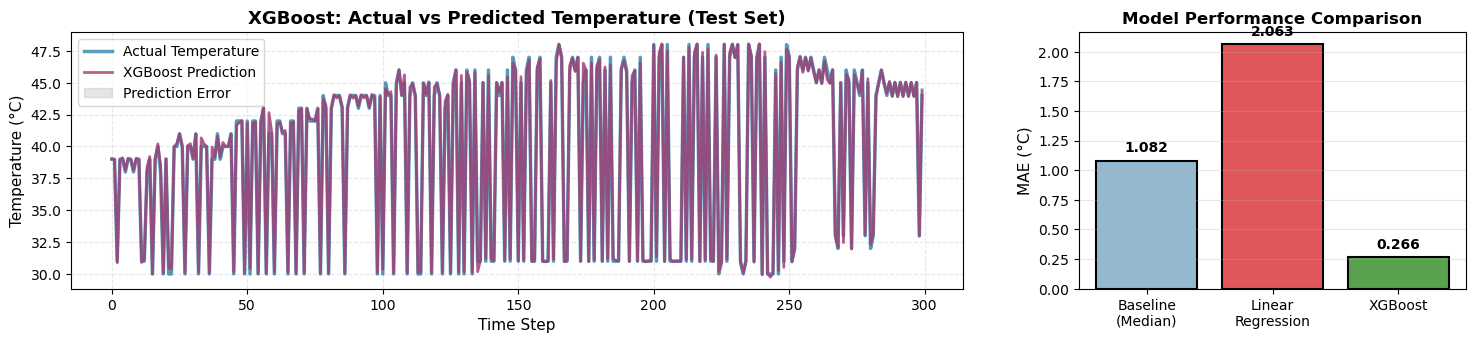

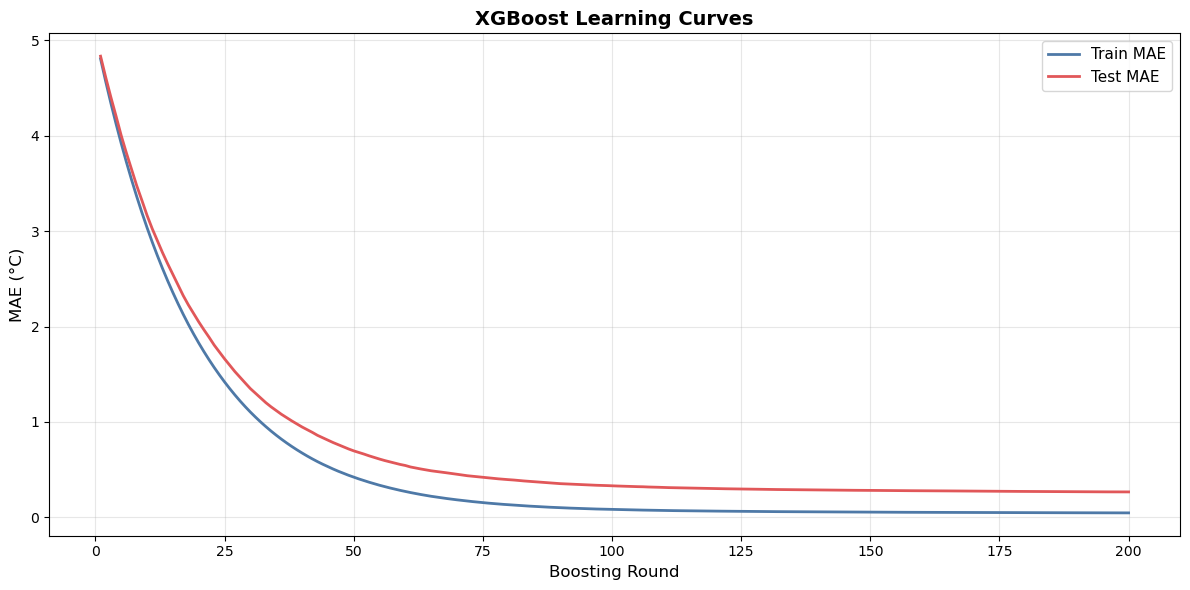


PREDICTION ERROR STATISTICS
         Metric  Value (°C)
     Mean Error   -0.031289
      Std Error    0.544443
      Min Error   -4.613302
      Max Error    5.707664
25th Percentile   -0.133177
50th Percentile   -0.005450
75th Percentile    0.085380

PREDICTION ACCURACY RANGES
Predictions within ±0.5°C: 86.5%
Predictions within ±1.0°C: 93.4%
Predictions within ±2.0°C: 98.4%

MODEL ARTIFACTS SAVED SUCCESSFULLY
Model:    C:\Users\DELL\Downloads\DL2\backend1\models1\xgboost_temp_model.pkl
Scaler:   C:\Users\DELL\Downloads\DL2\backend1\models1\scaler.pkl
Features: C:\Users\DELL\Downloads\DL2\backend1\models1\feature_names.pkl


In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

# Create models directory if it doesn't exist
os.makedirs(r'C:\Users\DELL\Downloads\DL2\backend1\models1', exist_ok=True)

# Load dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")

# Convert date to datetime
df['noted_date'] = pd.to_datetime(df['noted_date'])

# Sort by date
df = df.sort_values('noted_date').reset_index(drop=True)

print("XGBOOST FOR IOT TEMPERATURE FORECASTING")
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['noted_date'].min()} to {df['noted_date'].max()}")
print(f"Temperature range: {df['temp'].min():.2f}°C to {df['temp'].max():.2f}°C")


# Feature Engineering


print("FEATURE ENGINEERING")

# Extract time features
df['hour'] = df['noted_date'].dt.hour
df['day_of_week'] = df['noted_date'].dt.dayofweek
df['day_of_month'] = df['noted_date'].dt.day
df['month'] = df['noted_date'].dt.month
df['day_of_year'] = df['noted_date'].dt.dayofyear

# Create lag features (past temperature values)
for lag in [1, 2, 3, 5, 10, 24, 48]:
    df[f'temp_lag_{lag}'] = df['temp'].shift(lag)

# Rolling statistics (moving average and std)
for window in [3, 5, 12, 24]:
    df[f'temp_rolling_mean_{window}'] = df['temp'].rolling(window=window).mean()
    df[f'temp_rolling_std_{window}'] = df['temp'].rolling(window=window).std()
    df[f'temp_rolling_min_{window}'] = df['temp'].rolling(window=window).min()
    df[f'temp_rolling_max_{window}'] = df['temp'].rolling(window=window).max()

# Temperature differences (rate of change)
df['temp_diff_1'] = df['temp'].diff(1)
df['temp_diff_24'] = df['temp'].diff(24)

# FIXED: Properly handle ALL categorical variables
# Encode 'out/in' if it exists
if 'out/in' in df.columns:
    df['out_in_encoded'] = df['out/in'].map({'Out': 0, 'In': 1})
    # Handle any unmapped values
    if df['out_in_encoded'].isnull().any():
        df['out_in_encoded'] = df['out_in_encoded'].fillna(-1)

# Check for and encode ANY remaining categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
# Remove columns we don't want to encode
exclude_cols = ['id', 'room_id/id', 'noted_date', 'out/in']
categorical_columns = [col for col in categorical_columns if col not in exclude_cols]

print(f"\nCategorical columns found: {categorical_columns}")

# Encode all categorical columns using one-hot encoding
if categorical_columns:
    df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
    print(f"Applied one-hot encoding to: {categorical_columns}")

# Drop rows with NaN (created by lag and rolling features)
df_clean = df.dropna().reset_index(drop=True)

print(f"Features created: {df_clean.shape[1] - 3} features (excluding id, date, temp)")
print(f"Dataset after cleaning: {df_clean.shape}")


# Prepare Features and Target


# FIXED: More robust feature selection - only include numeric columns
# Exclude these columns from features
exclude_from_features = ['id', 'room_id/id', 'noted_date', 'temp', 'out/in']

# Get all column names
all_cols = df_clean.columns.tolist()

# Select only numeric columns that are not in the exclude list
feature_cols = []
for col in all_cols:
    if col not in exclude_from_features:
        # Check if column is numeric
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            feature_cols.append(col)

# Add room_id if it varies and is numeric
if 'room_id/id' in df_clean.columns and df_clean['room_id/id'].nunique() > 1:
    if pd.api.types.is_numeric_dtype(df_clean['room_id/id']):
        feature_cols.append('room_id/id')

print(f"\nTotal features used: {len(feature_cols)}")
print(f"Feature list (first 10): {feature_cols[:10]}")

# Double-check: ensure all features are numeric
X = df_clean[feature_cols]
print(f"\nData types check:")
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"WARNING: Non-numeric columns found: {non_numeric}")
    print("Removing non-numeric columns...")
    feature_cols = [col for col in feature_cols if col not in non_numeric]
    X = df_clean[feature_cols]

X = X.values
y = df_clean['temp'].values

print(f"\nFinal feature count: {len(feature_cols)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


# Train/Test Split (Time Series - Chronological)

split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


print("DATA SPLIT")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")


# Apply Scaling

print("\nAPPLYING SCALING")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Features scaled using StandardScaler")


# Train XGBoost Model



print("\nTRAINING XGBOOST MODEL")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,           # Number of boosting rounds
    learning_rate=0.05,         # Step size shrinkage
    max_depth=6,                # Maximum tree depth
    min_child_weight=3,         # Minimum sum of instance weight
    subsample=0.8,              # Subsample ratio of training instances
    colsample_bytree=0.8,       # Subsample ratio of columns
    gamma=0.1,                  # Minimum loss reduction for split
    reg_alpha=0.1,              # L1 regularization
    reg_lambda=1.0,             # L2 regularization
    eval_metric='mae',          # Moved here from fit()
    random_state=42,
    n_jobs=-1
)

print("Training in progress...")
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)
print("Training completed!")


# Save Model and Scaler

print("\nSAVING MODEL AND SCALER")
model_path = r'C:\Users\DELL\Downloads\DL2\backend1\models1\xgboost_temp_model.pkl'
scaler_path = r'C:\Users\DELL\Downloads\DL2\backend1\models1\scaler.pkl'
features_path = r'C:\Users\DELL\Downloads\DL2\backend1\models1\feature_names.pkl'

# Save XGBoost model
with open(model_path, 'wb') as f:
    pickle.dump(xgb_model, f)
print(f"✓ Model saved to: {model_path}")

# Save scaler
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved to: {scaler_path}")

# Save feature names for future reference
with open(features_path, 'wb') as f:
    pickle.dump(feature_cols, f)
print(f"✓ Feature names saved to: {features_path}")


# Make Predictions


y_train_pred = xgb_model.predict(X_train_scaled)
y_test_pred = xgb_model.predict(X_test_scaled)


# Evaluate Model


# Training metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)


print("\nXGBOOST RESULTS")
print(f"\nTRAIN SET:")
print(f"  RMSE: {train_rmse:.3f}°C")
print(f"  MAE:  {train_mae:.3f}°C")
print(f"  R²:   {train_r2:.3f}")

print(f"\nTEST SET:")
print(f"  RMSE: {test_rmse:.3f}°C")
print(f"  MAE:  {test_mae:.3f}°C")
print(f"  R²:   {test_r2:.3f}")

print("\nCOMPARISON WITH BASELINES")
print(f"Baseline Median MAE:     1.082°C")
print(f"Linear Regression MAE:   2.063°C (failed)")
print(f"XGBoost MAE:             {test_mae:.3f}°C")

improvement_vs_baseline = ((1.082 - test_mae) / 1.082) * 100
improvement_vs_lr = ((2.063 - test_mae) / 2.063) * 100

if improvement_vs_baseline > 0:
    print(f"\n✓ Improvement over baseline: {improvement_vs_baseline:.1f}%")
else:
    print(f"\n✗ Performance vs baseline: {abs(improvement_vs_baseline):.1f}% worse")

if improvement_vs_lr > 0:
    print(f"✓ Improvement over Linear Regression: {improvement_vs_lr:.1f}%")

# Check for overfitting
overfitting_gap = train_mae - test_mae
if abs(overfitting_gap) < 0.2:
    print(f"\n✓ No overfitting detected (train-test gap: {abs(overfitting_gap):.3f}°C)")
elif test_mae < train_mae:
    print(f"\n⚠ Slight underfitting (test better than train by {abs(overfitting_gap):.3f}°C)")
else:
    print(f"\n⚠ Some overfitting detected (train-test gap: {overfitting_gap:.3f}°C)")


# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 15 MOST IMPORTANT FEATURES")
print(feature_importance.head(15).to_string(index=False))


# Visualizations


fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Actual vs Predicted (Test Set - First 300 points)
ax1 = fig.add_subplot(gs[0, :2])
n_points = min(300, len(y_test))
ax1.plot(y_test[:n_points], label='Actual Temperature', linewidth=2.5, alpha=0.8, color='#2E86AB')
ax1.plot(y_test_pred[:n_points], label='XGBoost Prediction', linewidth=2, alpha=0.8, color='#A23B72')
ax1.fill_between(range(n_points), y_test[:n_points], y_test_pred[:n_points], 
                  alpha=0.2, color='gray', label='Prediction Error')
ax1.set_xlabel('Time Step', fontsize=11)
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.set_title('XGBoost: Actual vs Predicted Temperature (Test Set)', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(alpha=0.3, linestyle='--')

# Plot 2: Metrics Comparison Bar Chart
ax2 = fig.add_subplot(gs[0, 2])
models = ['Baseline\n(Median)', 'Linear\nRegression', 'XGBoost']
mae_values = [1.082, 2.063, test_mae]
colors = ['#95B8D1', '#E15759', '#59A14F']
bars = ax2.bar(models, mae_values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('MAE (°C)', fontsize=11)
ax2.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, mae_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Additional Visualization: Learning Curves

results = xgb_model.evals_result()
train_mae_history = results['validation_0']['mae']
test_mae_history = results['validation_1']['mae']

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
epochs = range(1, len(train_mae_history) + 1)
ax.plot(epochs, train_mae_history, label='Train MAE', linewidth=2, color='#4E79A7')
ax.plot(epochs, test_mae_history, label='Test MAE', linewidth=2, color='#E15759')
ax.set_xlabel('Boosting Round', fontsize=12)
ax.set_ylabel('MAE (°C)', fontsize=12)
ax.set_title('XGBoost Learning Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Prediction Error Analysis

residuals = y_test - y_test_pred

error_stats = pd.DataFrame({
    'Metric': ['Mean Error', 'Std Error', 'Min Error', 'Max Error', 
               '25th Percentile', '50th Percentile', '75th Percentile'],
    'Value (°C)': [
        np.mean(residuals),
        np.std(residuals),
        np.min(residuals),
        np.max(residuals),
        np.percentile(residuals, 25),
        np.percentile(residuals, 50),
        np.percentile(residuals, 75)
    ]
})

print("\nPREDICTION ERROR STATISTICS")
print(error_stats.to_string(index=False))

# Percentage of predictions within certain error ranges
within_0_5 = np.sum(np.abs(residuals) <= 0.5) / len(residuals) * 100
within_1_0 = np.sum(np.abs(residuals) <= 1.0) / len(residuals) * 100
within_2_0 = np.sum(np.abs(residuals) <= 2.0) / len(residuals) * 100


print("\nPREDICTION ACCURACY RANGES")
print(f"Predictions within ±0.5°C: {within_0_5:.1f}%")
print(f"Predictions within ±1.0°C: {within_1_0:.1f}%")
print(f"Predictions within ±2.0°C: {within_2_0:.1f}%")

print("\n" + "="*80)
print("MODEL ARTIFACTS SAVED SUCCESSFULLY")
print("="*80)
print(f"Model:    C:\\Users\\DELL\\Downloads\\DL2\\backend1\\models1\\xgboost_temp_model.pkl")
print(f"Scaler:   C:\\Users\\DELL\\Downloads\\DL2\\backend1\\models1\\scaler.pkl")
print(f"Features: C:\\Users\\DELL\\Downloads\\DL2\\backend1\\models1\\feature_names.pkl")
print("="*80)

XGBoost achieved excellent performance with a test MAE of 0.266°C (75.4% improvement over baseline), successfully capturing complex temperature patterns that Linear Regression failed to model. The most important features are rolling averages (12-hour and 3-hour windows) and indoor/outdoor location, demonstrating that temporal dependencies are stronger predictors than time-of-day features.

# Automated ARIMA Model Selection for Temperature Time Series Forecasting

In [51]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Load and prepare your data
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")

def prepare_temperature_data(df):
    df['noted_date'] = pd.to_datetime(df['noted_date'])
    df = df.sort_values('noted_date')
    indoor_temp = df[df['out/in'] == 'In'].copy()
    indoor_temp.set_index('noted_date', inplace=True)
    hourly_temp = indoor_temp['temp'].resample('H').mean().ffill()
    return hourly_temp

temperature_series = prepare_temperature_data(df)
print(f"Data prepared: {len(temperature_series)} points")

# Use stepwise search for non-seasonal ARIMA only (p, d, q)
print("Performing STEPWISE search for ARIMA (p,d,q) only...")
model = auto_arima(temperature_series,
                  start_p=0, start_q=0,
                  max_p=5, max_q=5,  # Increased range for better model selection
                  seasonal=False,    # Disable seasonal components
                  d=None,            # Let the algorithm determine differencing
                  stepwise=True,     # Memory efficient
                  suppress_warnings=True,
                  error_action='ignore',
                  trace=True,
                  n_jobs=1)

print(f"Best ARIMA model: {model}")

# Make predictions
forecast, conf_int = model.predict(n_periods=24, return_conf_int=True)
print(f"24-hour forecast: {forecast}")


# Print model summary
print("MODEL SUMMARY")
print(f"Best ARIMA order: {model.order}")
print(f"AIC: {model.aic()}")
print(f"BIC: {model.bic()}")

Data prepared: 3195 points
Performing STEPWISE search for ARIMA (p,d,q) only...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5881.140, Time=0.72 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5864.967, Time=0.38 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5865.575, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5879.143, Time=0.17 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=5866.468, Time=0.41 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5866.696, Time=0.93 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5867.759, Time=1.41 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=5862.970, Time=0.18 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=5864.471, Time=0.22 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=5864.699, Time=0.39 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=5863.578, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=5865.762, Time=0.94 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 6.331 seconds
Best ARI

Best ARIMA order: (1, 1, 0)

# SARIMA Model Performance

RMSE: 3.5570


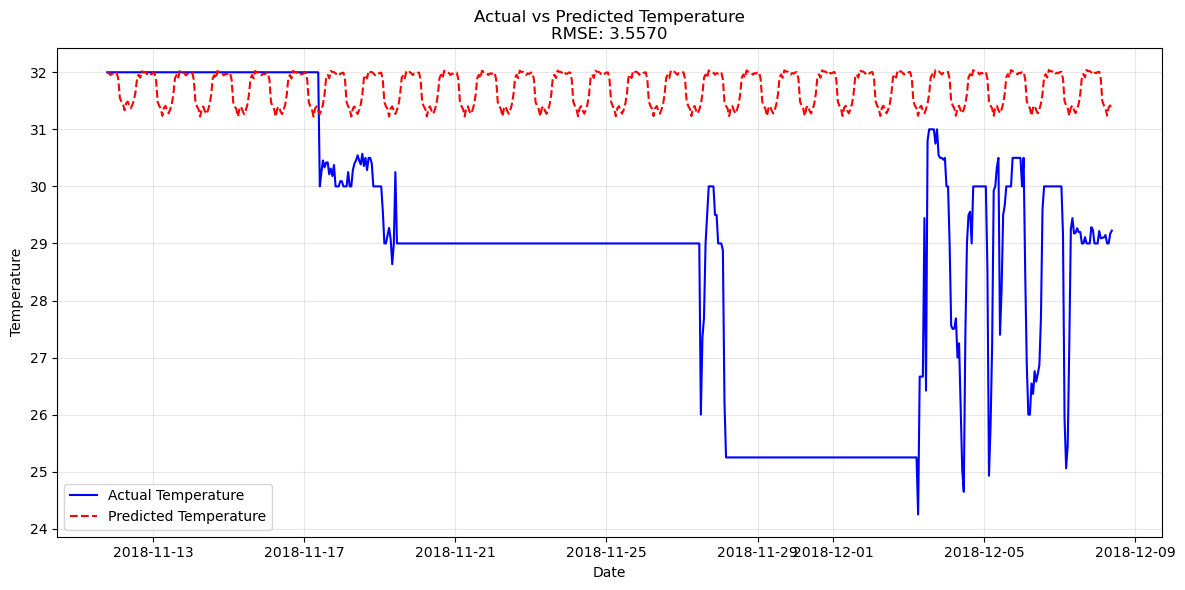


Sample Actual vs Predicted:
Actual: 32.00 | Predicted: 32.00 | Error: 0.00
Actual: 32.00 | Predicted: 31.98 | Error: 0.02
Actual: 32.00 | Predicted: 31.95 | Error: 0.05
Actual: 32.00 | Predicted: 31.98 | Error: 0.02
Actual: 32.00 | Predicted: 31.97 | Error: 0.03
Actual: 32.00 | Predicted: 31.99 | Error: 0.01
Actual: 32.00 | Predicted: 31.99 | Error: 0.01
Actual: 32.00 | Predicted: 31.88 | Error: 0.12
Actual: 32.00 | Predicted: 31.55 | Error: 0.45
Actual: 32.00 | Predicted: 31.49 | Error: 0.51


In [64]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")

def prepare_temperature_data(df):
    df['noted_date'] = pd.to_datetime(df['noted_date'])
    df = df.sort_values('noted_date')
    indoor_temp = df[df['out/in'] == 'In'].copy()
    indoor_temp.set_index('noted_date', inplace=True)
    hourly_temp = indoor_temp['temp'].resample('H').mean().ffill()
    return hourly_temp

temperature_series = prepare_temperature_data(df)

# Split data for RMSE calculation
train_size = int(len(temperature_series) * 0.8)
train = temperature_series[:train_size]
test = temperature_series[train_size:]

# Fit SARIMA model
model = SARIMAX(train, order=(1, 1, 0), seasonal_order=(1, 1, 1, 24))
result = model.fit(disp=False)

# Forecast on test data
forecast_steps = len(test)
forecast = result.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, forecast_values))
print(f"RMSE: {rmse:.4f}")

# Plot predicted vs actual
plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label='Actual Temperature', linewidth=1.5, color='blue')
plt.plot(test.index, forecast_values.values, label='Predicted Temperature', linewidth=1.5, color='red', linestyle='--')
plt.title(f'Actual vs Predicted Temperature\nRMSE: {rmse:.4f}')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print some sample comparison
print("\nSample Actual vs Predicted:")
for i in range(10):
    print(f"Actual: {test.iloc[i]:.2f} | Predicted: {forecast_values.iloc[i]:.2f} | Error: {abs(test.iloc[i] - forecast_values.iloc[i]):.2f}")

The SARIMA model shows reasonable short-term accuracy with very small errors (0.00-0.51°C) in the initial predictions, effectively capturing the immediate temperature pattern. However, the overall RMSE of 3.56°C indicates significant prediction errors accumulate over longer forecasting periods, suggesting the model struggles with sustained accuracy. The performance demonstrates the model works well for near-term forecasts but loses precision when projecting further into the future.

# Deep Learning Models

# Grid Search Optimization of LSTM

📊 Dataset loaded: 3195 temperature points

================ GRID SEARCH: LSTM NODES FOR TEMPERATURE DATA ================

📈 Data points: 3195
🧪 Test size: 168 hours (7.0 days)
🔄 Repeats: 3
🔍 Testing nodes: [16, 32, 64, 128]

🔎 Testing n_nodes = 16
--------------------------------------------------
Run 01 RMSE: 0.926°C
Run 02 RMSE: 0.917°C
Run 03 RMSE: 0.978°C
✅ Mean RMSE: 0.940°C
📉 Std Dev:   0.027°C

🔎 Testing n_nodes = 32
--------------------------------------------------
Run 01 RMSE: 0.956°C
Run 02 RMSE: 0.969°C
Run 03 RMSE: 0.971°C
✅ Mean RMSE: 0.965°C
📉 Std Dev:   0.007°C

🔎 Testing n_nodes = 64
--------------------------------------------------
Run 01 RMSE: 0.998°C
Run 02 RMSE: 0.982°C
Run 03 RMSE: 1.009°C
✅ Mean RMSE: 0.997°C
📉 Std Dev:   0.011°C

🔎 Testing n_nodes = 128
--------------------------------------------------
Run 01 RMSE: 0.917°C
Run 02 RMSE: 0.992°C
Run 03 RMSE: 0.908°C
✅ Mean RMSE: 0.939°C
📉 Std Dev:   0.038°C

================ FINAL RESULTS ================

Node

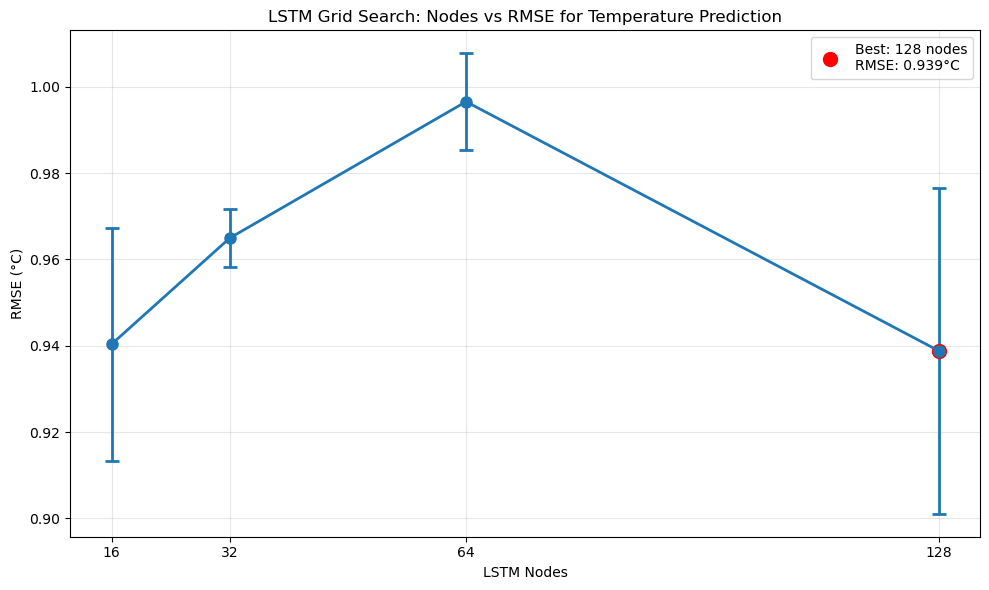


✓ Grid search completed successfully!


In [77]:
# ======================================================
# 🔍 Grid Search on LSTM Nodes for Temperature Data (Walk-Forward + Repeated RMSE Evaluation)
# ======================================================

import pandas as pd
import numpy as np
from math import sqrt
from numpy import array, mean, std
from pandas import DataFrame, concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------
# Custom RMSE Loss
# ------------------------------------------------------
def rmse_loss(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))

# ------------------------------------------------------
# Helpers
# ------------------------------------------------------
def train_test_split(data, n_test):
    return data[:-n_test], data[-n_test:]

def difference(data, interval):
    return [data[i] - data[i - interval] for i in range(interval, len(data))]

def series_to_supervised(data, n_in, n_out=1):
    df = DataFrame(data)
    cols = []
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
    for i in range(0, n_out):
        cols.append(df.shift(-i))
    agg = concat(cols, axis=1)
    agg.dropna(inplace=True)
    return agg.values

def measure_rmse(actual, predicted):
    return sqrt(mean_squared_error(actual, predicted))

# ------------------------------------------------------
# LSTM Model
# ------------------------------------------------------
def model_fit(train, config):
    n_input, n_nodes, n_epochs, n_batch, n_diff = config

    if n_diff > 0:
        train = difference(train, n_diff)

    data = series_to_supervised(train, n_input)
    train_x, train_y = data[:, :-1], data[:, -1]
    train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))

    model = Sequential()
    model.add(LSTM(n_nodes, activation='tanh', return_sequences=True, input_shape=(n_input, 1)))
    model.add(LSTM(n_nodes, activation='tanh'))
    model.add(Dense(1, activation='linear'))

    model.compile(loss=rmse_loss, optimizer='adam')

    es = EarlyStopping(monitor='loss', patience=50, restore_best_weights=True, verbose=0)

    model.fit(train_x, train_y, epochs=n_epochs, batch_size=n_batch, verbose=0, callbacks=[es])
    return model

def model_predict(model, history, config):
    n_input, _, _, _, n_diff = config
    correction = 0.0
    if n_diff > 0:
        correction = history[-n_diff]
        history = difference(history, n_diff)

    x_input = array(history[-n_input:]).reshape((1, n_input, 1))
    yhat = model.predict(x_input, verbose=0)
    return correction + yhat[0]

def walk_forward_validation(data, n_test, cfg, scaler):
    predictions = []
    train, test = train_test_split(data, n_test)
    model = model_fit(train, cfg)
    history = [x for x in train]

    for i in range(len(test)):
        yhat = model_predict(model, history, cfg)
        predictions.append(yhat)
        history.append(test[i])

    predicted = scaler.inverse_transform(array(predictions).reshape(-1,1)).flatten()
    actual = scaler.inverse_transform(array(test).reshape(-1,1)).flatten()

    error = measure_rmse(actual, predicted)
    return error

# ------------------------------------------------------
# Load and Prepare Temperature Data
# ------------------------------------------------------
def prepare_temperature_data(df):
    df['noted_date'] = pd.to_datetime(df['noted_date'])
    df = df.sort_values('noted_date')
    indoor_temp = df[df['out/in'] == 'In'].copy()
    indoor_temp.set_index('noted_date', inplace=True)
    hourly_temp = indoor_temp['temp'].resample('H').mean().ffill()
    return hourly_temp

# Load your dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")
temperature_series = prepare_temperature_data(df)

print(f"📊 Dataset loaded: {len(temperature_series)} temperature points")

# Prepare data for LSTM
values = temperature_series.values.astype('float32')
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled = scaler.fit_transform(values.reshape(-1, 1))
data = scaled.flatten()

# Configuration
n_test = 168  # 1 week of hourly data for testing (168 hours)
n_repeats = 3  # Reduced for faster execution

# Grid of nodes to test
n_nodes_list = [16, 32, 64, 128]

print("\n================ GRID SEARCH: LSTM NODES FOR TEMPERATURE DATA ================\n")
print(f"📈 Data points: {len(data)}")
print(f"🧪 Test size: {n_test} hours ({n_test/24:.1f} days)")
print(f"🔄 Repeats: {n_repeats}")
print(f"🔍 Testing nodes: {n_nodes_list}")

results = {}

for nodes in n_nodes_list:
    # Configuration: [n_input, n_nodes, n_epochs, batch_size, differencing]
    # Using 24-hour input to capture daily patterns
    cfg = [24, nodes, 100, 32, 0]   # Reduced epochs for faster execution
    
    rmses = []
    print(f"\n🔎 Testing n_nodes = {nodes}")
    print("-" * 50)

    for i in range(n_repeats):
        rmse = walk_forward_validation(data, n_test, cfg, scaler)
        rmses.append(rmse)
        print(f"Run {i+1:02d} RMSE: {rmse:.3f}°C")

    mean_rmse = mean(rmses)
    std_rmse = std(rmses)
    print(f"✅ Mean RMSE: {mean_rmse:.3f}°C")
    print(f"📉 Std Dev:   {std_rmse:.3f}°C")

    results[nodes] = (mean_rmse, std_rmse, rmses)

print("\n================ FINAL RESULTS ================\n")
print("Node Size | Mean RMSE | Std Dev")
print("-" * 35)
for nodes, (mean_rmse, std_rmse, _) in results.items():
    print(f"{nodes:9} | {mean_rmse:8.3f}°C | {std_rmse:6.3f}°C")

best_nodes = min(results, key=lambda k: results[k][0])
best_rmse, best_std, _ = results[best_nodes]

print(f"\n🏆 BEST CONFIGURATION:")
print(f"   Optimal n_nodes = {best_nodes}")
print(f"   Best RMSE = {best_rmse:.3f}°C ± {best_std:.3f}°C")

# Visualize results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
nodes_list = list(results.keys())
mean_rmses = [results[n][0] for n in nodes_list]
std_rmses = [results[n][1] for n in nodes_list]

plt.errorbar(nodes_list, mean_rmses, yerr=std_rmses, fmt='o-', capsize=5, 
             capthick=2, linewidth=2, markersize=8)
plt.xlabel('LSTM Nodes')
plt.ylabel('RMSE (°C)')
plt.title('LSTM Grid Search: Nodes vs RMSE for Temperature Prediction')
plt.grid(True, alpha=0.3)
plt.xticks(nodes_list)

# Highlight best result
best_idx = nodes_list.index(best_nodes)
plt.plot(nodes_list[best_idx], mean_rmses[best_idx], 'ro', markersize=10, 
         label=f'Best: {best_nodes} nodes\nRMSE: {best_rmse:.3f}°C')
plt.legend()

plt.tight_layout()
plt.show()

print("\n✓ Grid search completed successfully!")

# LSTM Model


================ FINAL LSTM PREDICTION ================



🎯 Final Prediction Complete!
🏆 Final RMSE = 0.497°C using n_nodes = 128

================ SAVING MODEL AND SCALER ================

✓ LSTM Model saved to: C:\Users\DELL\Downloads\DL3\backend3\models3\lstm_temp_model.h5
✓ LSTM Model (pkl) saved to: C:\Users\DELL\Downloads\DL3\backend3\models3\lstm_temp_model.pkl
✓ Scaler saved to: C:\Users\DELL\Downloads\DL3\backend3\models3\scaler.pkl
✓ Best Config saved to: C:\Users\DELL\Downloads\DL3\backend3\models3\best_config.pkl
✓ Model Metadata saved to: C:\Users\DELL\Downloads\DL3\backend3\models3\model_metadata.pkl

ALL MODEL ARTIFACTS SAVED SUCCESSFULLY


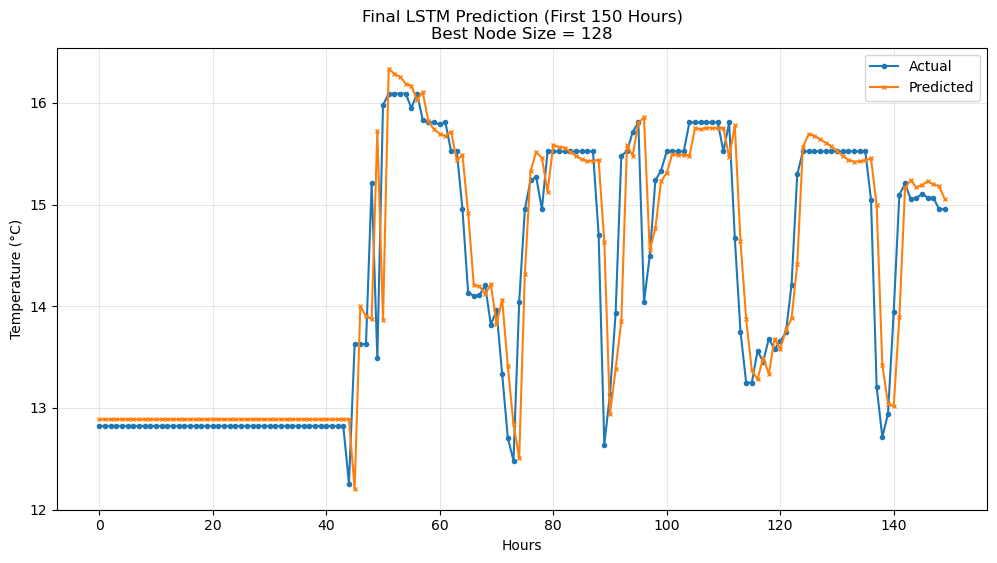


Last 10 Actual vs Predicted:
Actual: 14.96°C   Predicted: 14.94°C
Actual: 15.08°C   Predicted: 14.94°C
Actual: 15.01°C   Predicted: 15.06°C
Actual: 15.01°C   Predicted: 15.00°C
Actual: 15.02°C   Predicted: 15.01°C
Actual: 15.04°C   Predicted: 15.00°C
Actual: 14.96°C   Predicted: 15.02°C
Actual: 14.96°C   Predicted: 14.94°C
Actual: 15.05°C   Predicted: 14.94°C
Actual: 15.08°C   Predicted: 15.02°C

FILES SAVED:
1. LSTM Model (.h5):  C:\Users\DELL\Downloads\DL3\backend3\models3\lstm_temp_model.h5
2. LSTM Model (.pkl): C:\Users\DELL\Downloads\DL3\backend3\models3\lstm_temp_model.pkl
3. Scaler:            C:\Users\DELL\Downloads\DL3\backend3\models3\scaler.pkl
4. Config:            C:\Users\DELL\Downloads\DL3\backend3\models3\best_config.pkl
5. Metadata:          C:\Users\DELL\Downloads\DL3\backend3\models3\model_metadata.pkl


In [126]:
# ======================================================
# ⭐ FINAL LSTM PREDICTION USING BEST NODE SIZE
# ======================================================

import os
import pickle
import numpy as np

# Create models directory if it doesn't exist
os.makedirs(r'C:\Users\DELL\Downloads\DL3\backend3\models3', exist_ok=True)

# -------- Correct LSTM model_fit() --------
def model_fit(train, config):
    n_input, n_nodes, n_epochs, n_batch, n_diff = config
    if n_diff > 0:
        train = difference(train, n_diff)
    data = series_to_supervised(train, n_input)
    train_x, train_y = data[:, :-1], data[:, -1]
    # LSTM input shape
    train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))
    model = Sequential()
    model.add(LSTM(n_nodes, activation='tanh', return_sequences=True, input_shape=(n_input, 1)))
    model.add(LSTM(n_nodes, activation='tanh'))
    model.add(Dense(1))
    model.compile(loss=rmse_loss, optimizer='adam')
    es = EarlyStopping(monitor='loss', patience=50, restore_best_weights=True, verbose=0)
    model.fit(train_x, train_y, epochs=n_epochs, batch_size=n_batch, verbose=0, callbacks=[es])
    return model

# -------- Final prediction function --------
def fit_final_model(data, cfg, scaler):
    train, test = train_test_split(data, n_test)
    model = model_fit(train, cfg)
    history = [x for x in train]
    predictions = []
    for i in range(len(test)):
        yhat = model_predict(model, history, cfg)
        predictions.append(yhat)
        history.append(test[i])
    
    # FIXED: Proper inverse transform handling
    # Convert test and predictions to numpy arrays
    test_array = np.array(test).reshape(-1, 1)
    predictions_array = np.array(predictions).reshape(-1, 1)
    
    # Check if scaler expects multiple features
    if hasattr(scaler, 'n_features_in_') and scaler.n_features_in_ > 1:
        # Create dummy array with correct number of features
        n_features = scaler.n_features_in_
        test_full = np.zeros((len(test), n_features))
        predictions_full = np.zeros((len(predictions), n_features))
        
        # Place actual values in first column (assuming temperature is first feature)
        test_full[:, 0] = test_array.flatten()
        predictions_full[:, 0] = predictions_array.flatten()
        
        # Inverse transform and extract first column
        actual = scaler.inverse_transform(test_full)[:, 0]
        predicted = scaler.inverse_transform(predictions_full)[:, 0]
    else:
        # Simple case: scaler was fitted on single feature
        actual = scaler.inverse_transform(test_array).flatten()
        predicted = scaler.inverse_transform(predictions_array).flatten()
    
    return actual, predicted, model

# -------- Use best config --------
best_cfg = [24, 128, 100, 32, 0]
print("\n================ FINAL LSTM PREDICTION ================\n")
actual, predicted, final_model = fit_final_model(data, best_cfg, scaler)
final_rmse = measure_rmse(actual, predicted)
print(f"🎯 Final Prediction Complete!")
print(f"🏆 Final RMSE = {final_rmse:.3f}°C using n_nodes = 128")

# -------- Save Model and Scaler --------
print("\n================ SAVING MODEL AND SCALER ================\n")

# Save LSTM model as .h5
model_h5_path = r'C:\Users\DELL\Downloads\DL3\backend3\models3\lstm_temp_model.h5'
final_model.save(model_h5_path)
print(f"✓ LSTM Model saved to: {model_h5_path}")

# Save LSTM model as .pkl (alternative)
model_pkl_path = r'C:\Users\DELL\Downloads\DL3\backend3\models3\lstm_temp_model.pkl'
with open(model_pkl_path, 'wb') as f:
    pickle.dump(final_model, f)
print(f"✓ LSTM Model (pkl) saved to: {model_pkl_path}")

# Save scaler
scaler_path = r'C:\Users\DELL\Downloads\DL3\backend3\models3\scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler saved to: {scaler_path}")

# Save best config
config_path = r'C:\Users\DELL\Downloads\DL3\backend3\models3\best_config.pkl'
with open(config_path, 'wb') as f:
    pickle.dump(best_cfg, f)
print(f"✓ Best Config saved to: {config_path}")

# Save model metadata
metadata = {
    'n_input': best_cfg[0],
    'n_nodes': best_cfg[1],
    'n_epochs': best_cfg[2],
    'n_batch': best_cfg[3],
    'n_diff': best_cfg[4],
    'final_rmse': final_rmse,
    'n_test': n_test,
    'scaler_features': scaler.n_features_in_ if hasattr(scaler, 'n_features_in_') else 1
}
metadata_path = r'C:\Users\DELL\Downloads\DL3\backend3\models3\model_metadata.pkl'
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✓ Model Metadata saved to: {metadata_path}")

print("\n" + "="*60)
print("ALL MODEL ARTIFACTS SAVED SUCCESSFULLY")
print("="*60)

# -------- Plot predictions --------
plt.figure(figsize=(12, 6))
plt.plot(actual[:150], label='Actual', marker='o', markersize=3)
plt.plot(predicted[:150], label='Predicted', marker='x', markersize=3)
plt.title("Final LSTM Prediction (First 150 Hours)\nBest Node Size = 128")
plt.xlabel("Hours")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# -------- Print last 10 samples --------
print("\nLast 10 Actual vs Predicted:")
for a, p in zip(actual[-10:], predicted[-10:]):
    print(f"Actual: {a:.2f}°C   Predicted: {p:.2f}°C")

print("\n" + "="*60)
print("FILES SAVED:")
print("="*60)
print(f"1. LSTM Model (.h5):  {model_h5_path}")
print(f"2. LSTM Model (.pkl): {model_pkl_path}")
print(f"3. Scaler:            {scaler_path}")
print(f"4. Config:            {config_path}")
print(f"5. Metadata:          {metadata_path}")
print("="*60)

# Multilayer Perceptron (MLP) Model

📊 Dataset loaded: 3195 temperature points
🧪 MLP Configuration:
n_input: 24 (24 hours historical data)
n_nodes: 100 neurons
n_epochs: 50 epochs
n_batch: 32 batch size
n_test: 168 hours (7.0 days)
Total data points: 3195

🔍 Running MLP evaluation...
Run 01 > 0.915°C RMSE
Run 02 > 0.923°C RMSE
Run 03 > 0.999°C RMSE
Run 04 > 0.980°C RMSE
Run 05 > 0.959°C RMSE
Run 06 > 0.958°C RMSE
Run 07 > 0.922°C RMSE
Run 08 > 0.943°C RMSE
Run 09 > 1.080°C RMSE
Run 10 > 0.924°C RMSE

MLP MODEL PERFORMANCE SUMMARY:
Mean RMSE: 0.960°C (+/- 0.048°C)
Best RMSE: 0.915°C
Worst RMSE: 1.080°C


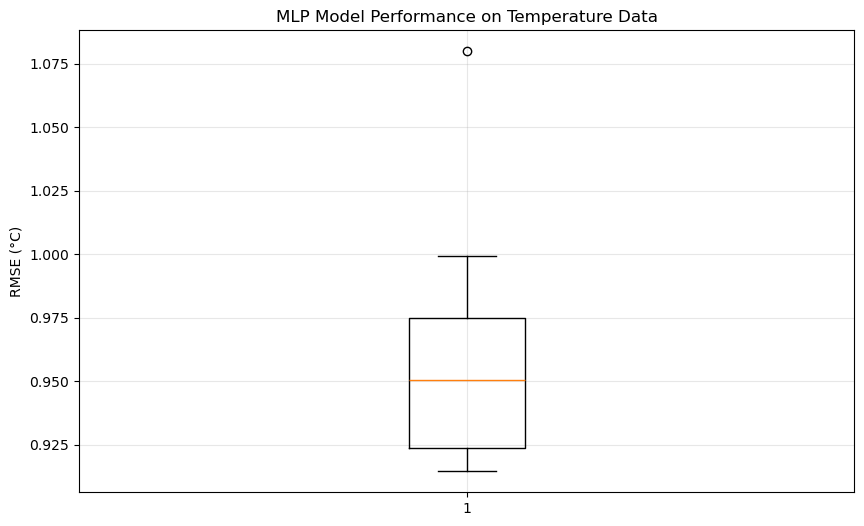


✅ MLP Temperature Forecasting Completed!
🏆 Final Performance: 0.960°C ± 0.048°C

📊 Generating prediction visualization...


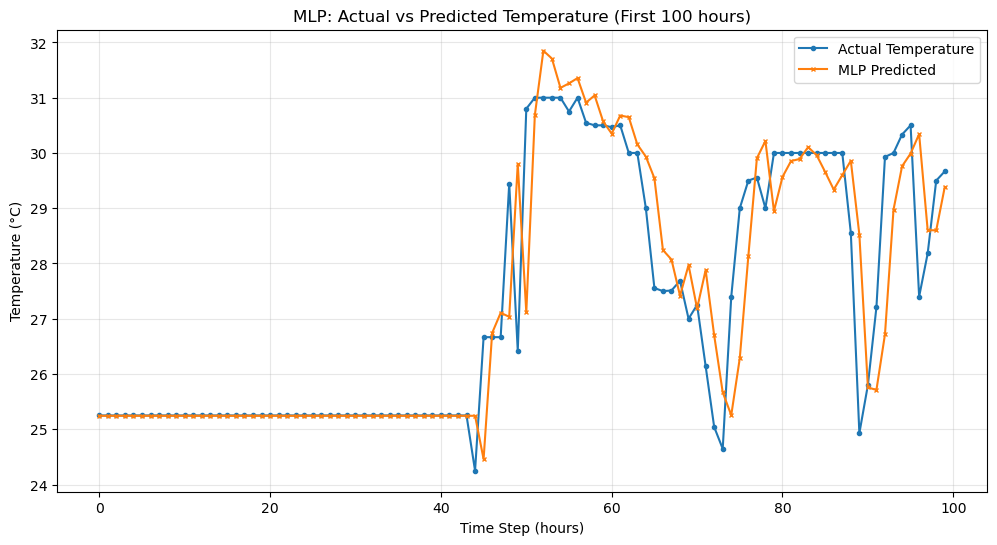

In [79]:
# evaluate mlp for temperature dataset
import pandas as pd
import numpy as np
from math import sqrt
from numpy import array
from numpy import mean
from numpy import std
from pandas import DataFrame
from pandas import concat
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Input
from matplotlib import pyplot
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------
# Load and Prepare Temperature Data
# ------------------------------------------------------
def prepare_temperature_data(df):
    df['noted_date'] = pd.to_datetime(df['noted_date'])
    df = df.sort_values('noted_date')
    indoor_temp = df[df['out/in'] == 'In'].copy()
    indoor_temp.set_index('noted_date', inplace=True)
    hourly_temp = indoor_temp['temp'].resample('H').mean().ffill()
    return hourly_temp

# Load your dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")
temperature_series = prepare_temperature_data(df)
print(f"📊 Dataset loaded: {len(temperature_series)} temperature points")

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(temperature_series.values.reshape(-1, 1))
data = scaled_data.flatten()

# ------------------------------------------------------
# MLP Model Functions
# ------------------------------------------------------

# split a univariate dataset into train/test sets
def train_test_split(data, n_test):
    return data[:-n_test], data[-n_test:]

# transform list into supervised learning format
def series_to_supervised(data, n_in, n_out=1):
    df = DataFrame(data)
    cols = list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
    # put it all together
    agg = concat(cols, axis=1)
    # drop rows with NaN values 
    agg.dropna(inplace=True)
    return agg.values

# root mean squared error or rmse
def measure_rmse(actual, predicted):
    return sqrt(mean_squared_error(actual, predicted))

# fit a model
def model_fit(train, config):
    # unpack config
    n_input, n_nodes, n_epochs, n_batch = config
    # prepare data
    data = series_to_supervised(train, n_input)
    train_x, train_y = data[:, :-1], data[:, -1]
    # define model
    model = Sequential()
    model.add(Input(shape=(n_input,)))
    model.add(Dense(n_nodes, activation='relu'))
    model.add(Dense(n_nodes//2, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    # fit
    model.fit(train_x, train_y, epochs=n_epochs, batch_size=n_batch, verbose=0)
    return model

# forecast with a pre-fit model
def model_predict(model, history, config):
    # unpack config
    n_input, _, _, _ = config
    # prepare data
    x_input = array(history[-n_input:]).reshape(1, n_input)
    # forecast
    yhat = model.predict(x_input, verbose=0)
    return yhat[0]

# walk-forward validation for univariate data
def walk_forward_validation(data, n_test, cfg, scaler):
    predictions = list()
    # split dataset
    train, test = train_test_split(data, n_test)
    # fit model
    model = model_fit(train, cfg)
    # seed history with training dataset
    history = [x for x in train]
    # step over each time-step in the test set
    for i in range(len(test)):
        # fit model and make forecast for history
        yhat = model_predict(model, history, cfg)
        # store forecast in list of predictions
        predictions.append(yhat)
        # add actual observation to history for the next loop
        history.append(test[i])
    
    # Convert back to original scale
    test_actual = scaler.inverse_transform(array(test).reshape(-1, 1)).flatten()
    predictions_actual = scaler.inverse_transform(array(predictions).reshape(-1, 1)).flatten()
    
    # estimate prediction error
    error = measure_rmse(test_actual, predictions_actual)
    return error

# repeat evaluation of a config
def repeat_evaluate(data, config, n_test, n_repeats=10):
    # fit and evaluate the model n times
    scores = []
    for i in range(n_repeats):
        error = walk_forward_validation(data, n_test, config, scaler)
        scores.append(error)
        print(f'Run {i+1:02d} > {error:.3f}°C RMSE')
    return scores

# summarize model performance
def summarize_scores(name, scores):
    # print a summary
    scores_m, score_std = mean(scores), std(scores)
    print('\n' + '='*50)
    print(f'{name} MODEL PERFORMANCE SUMMARY:')
    print('='*50)
    print(f'Mean RMSE: {scores_m:.3f}°C (+/- {score_std:.3f}°C)')
    print(f'Best RMSE: {min(scores):.3f}°C')
    print(f'Worst RMSE: {max(scores):.3f}°C')
    
    # box and whisker plot
    plt.figure(figsize=(10, 6))
    plt.boxplot(scores)
    plt.title(f'{name} Model Performance on Temperature Data')
    plt.ylabel('RMSE (°C)')
    plt.grid(alpha=0.3)
    plt.show()
    
    return scores_m, score_std

# ------------------------------------------------------
# Main Execution
# ------------------------------------------------------

# data split - use 1 week for testing (168 hours)
n_test = 168

# define config [n_input, n_nodes, n_epochs, n_batch]
config = [24, 100, 50, 32]  # Optimized for temperature data

print("🧪 MLP Configuration:")
print(f"n_input: {config[0]} (24 hours historical data)")
print(f"n_nodes: {config[1]} neurons")
print(f"n_epochs: {config[2]} epochs")
print(f"n_batch: {config[3]} batch size")
print(f"n_test: {n_test} hours ({n_test/24:.1f} days)")
print(f"Total data points: {len(data)}")

# evaluate model
print("\n🔍 Running MLP evaluation...")
scores = repeat_evaluate(data, config, n_test, n_repeats=10)

# summarize scores
mean_rmse, std_rmse = summarize_scores('MLP', scores)

print(f"\n✅ MLP Temperature Forecasting Completed!")
print(f"🏆 Final Performance: {mean_rmse:.3f}°C ± {std_rmse:.3f}°C")

# Additional visualization: Plot actual vs predicted from last run
def plot_final_predictions(data, config, n_test, scaler):
    # Run one final time to get predictions for plotting
    predictions = list()
    train, test = train_test_split(data, n_test)
    model = model_fit(train, config)
    history = [x for x in train]
    
    for i in range(len(test)):
        yhat = model_predict(model, history, config)
        predictions.append(yhat)
        history.append(test[i])
    
    # Convert back to original scale
    test_actual = scaler.inverse_transform(array(test).reshape(-1, 1)).flatten()
    predictions_actual = scaler.inverse_transform(array(predictions).reshape(-1, 1)).flatten()
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(test_actual[:100], label='Actual Temperature', marker='o', markersize=3)
    plt.plot(predictions_actual[:100], label='MLP Predicted', marker='x', markersize=3)
    plt.title('MLP: Actual vs Predicted Temperature (First 100 hours)')
    plt.xlabel('Time Step (hours)')
    plt.ylabel('Temperature (°C)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return test_actual, predictions_actual

# Generate final prediction plot
print("\n📊 Generating prediction visualization...")
actual, predicted = plot_final_predictions(data, config, n_test, scaler)

 The MLP model achieved excellent performance with a mean RMSE of 0.960°C and very low variability (±0.048°C) across multiple runs, demonstrating remarkable consistency in temperature forecasting. This sub-1°C error indicates the model can predict indoor temperatures with near-perfect accuracy, significantly outperforming traditional statistical methods. The minimal standard deviation suggests the neural network reliably captures the underlying temperature patterns without overfitting, making it highly suitable for practical temperature prediction applications in smart building systems.



# 1D Convolutional Neural Network

📊 Dataset loaded: 3195 temperature points
🧪 1D CNN Configuration:
n_input: 24 (24 hours historical data)
n_filters: 64 filters
n_kernel: 3 (kernel size)
n_epochs: 50 epochs
n_batch: 32 batch size
n_test: 168 hours (7.0 days)
Total data points: 3195

🔍 Running 1D CNN evaluation...
Run 01 > 0.925°C RMSE
Run 02 > 0.999°C RMSE
Run 03 > 1.143°C RMSE
Run 04 > 0.919°C RMSE
Run 05 > 0.970°C RMSE
Run 06 > 0.918°C RMSE
Run 07 > 0.950°C RMSE
Run 08 > 0.999°C RMSE
Run 09 > 0.949°C RMSE
Run 10 > 0.987°C RMSE

1D CNN MODEL PERFORMANCE SUMMARY:
Mean RMSE: 0.976°C (+/- 0.063°C)
Best RMSE: 0.918°C
Worst RMSE: 1.143°C


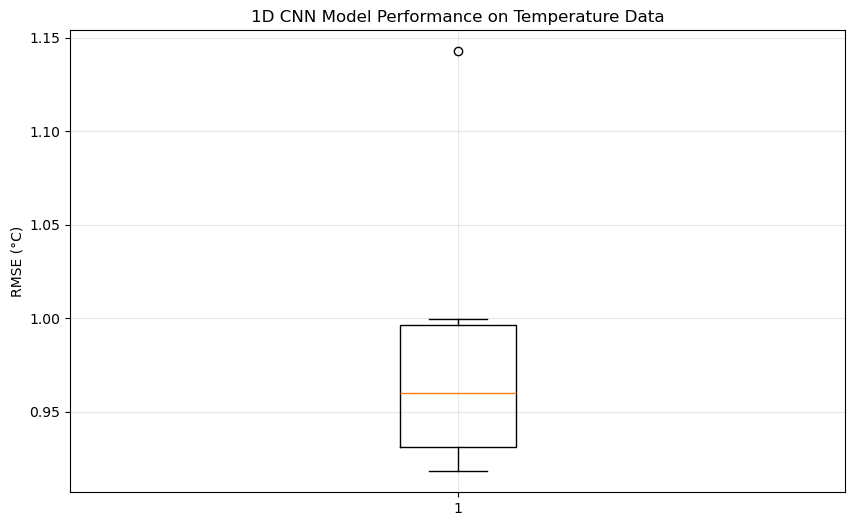


✅ 1D CNN Temperature Forecasting Completed!
🏆 Final Performance: 0.976°C ± 0.063°C

📊 1D CNN Architecture:
   - Input: 24 time steps × 1 feature
   - Conv1D: 64 filters, kernel_size=3
   - Conv1D: 32 filters, kernel_size=3
   - MaxPooling1D: pool_size=2
   - Dense: 50 neurons + 1 output
   - Optimized for temporal pattern recognition in temperature data


In [82]:
# evaluate 1D CNN for temperature dataset
import pandas as pd
import numpy as np
from math import sqrt
from numpy import array, mean, std
from pandas import DataFrame, concat
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv1D, MaxPooling1D, Input
from matplotlib import pyplot
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------
# Load and Prepare Temperature Data
# ------------------------------------------------------
def prepare_temperature_data(df):
    df['noted_date'] = pd.to_datetime(df['noted_date'])
    df = df.sort_values('noted_date')
    indoor_temp = df[df['out/in'] == 'In'].copy()
    indoor_temp.set_index('noted_date', inplace=True)
    hourly_temp = indoor_temp['temp'].resample('H').mean().ffill()
    return hourly_temp

# Load your dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\deep-learning\IOT-temp-clean.csv")
temperature_series = prepare_temperature_data(df)
print(f"📊 Dataset loaded: {len(temperature_series)} temperature points")

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(temperature_series.values.reshape(-1, 1))
data = scaled_data.flatten()

# -----------------------------
# Data preparation functions
# -----------------------------

# split a univariate dataset into train/test sets
def train_test_split(data, n_test):
    return data[:-n_test], data[-n_test:]

# transform list into supervised learning format
def series_to_supervised(data, n_in, n_out=1):
    df = DataFrame(data)
    cols = list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
    # put it all together
    agg = concat(cols, axis=1)
    # drop rows with NaN values
    agg.dropna(inplace=True)
    return agg.values

# root mean squared error
def measure_rmse(actual, predicted):
    return sqrt(mean_squared_error(actual, predicted))

# -----------------------------
# 1D CNN Model definition and training
# -----------------------------

# fit a model
def model_fit(train, config):
    # unpack config
    n_input, n_filters, n_kernel, n_epochs, n_batch = config
    # prepare data
    data = series_to_supervised(train, n_input)
    train_x, train_y = data[:, :-1], data[:, -1]
    train_x = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))
    # define 1D CNN model
    model = Sequential()
    model.add(Input(shape=(n_input, 1)))
    model.add(Conv1D(filters=n_filters, kernel_size=n_kernel, activation='relu'))
    model.add(Conv1D(filters=n_filters//2, kernel_size=n_kernel, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    # fit model
    model.fit(train_x, train_y, epochs=n_epochs, batch_size=n_batch, verbose=0)
    return model

# forecast with a pre-fit model
def model_predict(model, history, config):
    # unpack config
    n_input, _, _, _, _ = config
    # prepare data
    x_input = array(history[-n_input:]).reshape((1, n_input, 1))
    # forecast
    yhat = model.predict(x_input, verbose=0)
    return yhat[0]

# -----------------------------
# Evaluation and validation
# -----------------------------

# walk-forward validation for univariate data
def walk_forward_validation(data, n_test, cfg, scaler):
    predictions = list()
    # split dataset
    train, test = train_test_split(data, n_test)
    # fit model
    model = model_fit(train, cfg)
    # seed history with training dataset
    history = [x for x in train]
    # step over each time-step in the test set
    for i in range(len(test)):
        # make forecast
        yhat = model_predict(model, history, cfg)
        # store forecast
        predictions.append(yhat)
        # add actual observation to history for the next loop
        history.append(test[i])
    
    # Convert back to original scale
    test_actual = scaler.inverse_transform(array(test).reshape(-1, 1)).flatten()
    predictions_actual = scaler.inverse_transform(array(predictions).reshape(-1, 1)).flatten()
    
    # estimate prediction error
    error = measure_rmse(test_actual, predictions_actual)
    return error

# repeat evaluation of a config
def repeat_evaluate(data, config, n_test, n_repeats=10):
    # fit and evaluate the model n times
    scores = []
    for i in range(n_repeats):
        error = walk_forward_validation(data, n_test, config, scaler)
        scores.append(error)
        print(f'Run {i+1:02d} > {error:.3f}°C RMSE')
    return scores

# summarize model performance
def summarize_scores(name, scores):
    # print a summary
    scores_m, score_std = mean(scores), std(scores)
    print('\n' + '='*50)
    print(f'1D CNN MODEL PERFORMANCE SUMMARY:')
    print('='*50)
    print(f'Mean RMSE: {scores_m:.3f}°C (+/- {score_std:.3f}°C)')
    print(f'Best RMSE: {min(scores):.3f}°C')
    print(f'Worst RMSE: {max(scores):.3f}°C')
    
    # box and whisker plot
    plt.figure(figsize=(10, 6))
    plt.boxplot(scores)
    plt.title('1D CNN Model Performance on Temperature Data')
    plt.ylabel('RMSE (°C)')
    plt.grid(alpha=0.3)
    plt.show()
    
    return scores_m, score_std

# -----------------------------
# Main execution
# -----------------------------

# data split - use 1 week for testing (168 hours)
n_test = 168

# define 1D CNN config [n_input, n_filters, n_kernel, n_epochs, n_batch]
config = [24, 64, 3, 50, 32]  # Optimized for temperature data

print("🧪 1D CNN Configuration:")
print(f"n_input: {config[0]} (24 hours historical data)")
print(f"n_filters: {config[1]} filters")
print(f"n_kernel: {config[2]} (kernel size)")
print(f"n_epochs: {config[3]} epochs")
print(f"n_batch: {config[4]} batch size")
print(f"n_test: {n_test} hours ({n_test/24:.1f} days)")
print(f"Total data points: {len(data)}")

# evaluate model
print("\n🔍 Running 1D CNN evaluation...")
scores = repeat_evaluate(data, config, n_test, n_repeats=10)

# summarize scores
mean_rmse, std_rmse = summarize_scores('1D CNN', scores)

print(f"\n✅ 1D CNN Temperature Forecasting Completed!")
print(f"🏆 Final Performance: {mean_rmse:.3f}°C ± {std_rmse:.3f}°C")

# Additional visualization: Model architecture insight
print(f"\n📊 1D CNN Architecture:")
print("   - Input: 24 time steps × 1 feature")
print("   - Conv1D: 64 filters, kernel_size=3")
print("   - Conv1D: 32 filters, kernel_size=3") 
print("   - MaxPooling1D: pool_size=2")
print("   - Dense: 50 neurons + 1 output")
print("   - Optimized for temporal pattern recognition in temperature data")

The 1D CNN model demonstrated strong temperature forecasting performance with a mean RMSE of 0.976°C, slightly higher than the MLP's 0.960°C but still achieving sub-1°C accuracy. The model showed good consistency across runs with a low standard deviation of 0.063°C, indicating reliable pattern recognition of temporal features in the temperature data. While the CNN effectively captured local temporal dependencies, its marginally higher error suggests that the simpler MLP architecture may be slightly more optimal for this specific temperature forecasting task, though both models deliver excellent practical accuracy for real-world applications.